# 🎓 Master Notebook: Minería de Datos y Aprendizaje Automático
### Cátedra: Ronchetti — Hasperué | Facultad de Informática, Universidad Nacional de La Plata (UNLP)
**Ciclo Académico 2026** • *Guía Integral de Fundamentos Teóricos, Desgloses Matemáticos e Implementaciones Vectorizadas (Clases 1 a 5)*

---

## 📌 Presentación y Objetivos del Cuaderno
Este cuaderno interactivo constituye la referencia académica y práctica unificada para las primeras 5 clases de la cátedra de **Minería de Datos y Aprendizaje Automático**. Cada módulo combina:
1. **Rigor Teórico y Analítico**: Fórmulas matemáticas completas en $\LaTeX$ con desglose minucioso de cada variable y sumatoria.
2. **Implementación Artesanal (From Scratch)**: Código vectorizado en **NumPy** para comprender el funcionamiento interno de los algoritmos sin depender ciegamente de librerías.
3. **Validación en Entornos de Producción**: Contrastación directa contra implementaciones optimizadas de **Scikit-Learn** y **SciPy**.
4. **Buenas Prácticas Metodológicas**: Prevención de *Data Leakage*, diagnóstico de *Overfitting/Underfitting* y selección informada de métricas.

---

## 📑 Índice General Interactivo
* **[Clase 1: Fundamentos de IA, KDD vs. CRISP-DM & Métricas de Distancia](#clase-1)**
  * [1.1 Ciclo de Vida: Metodología KDD vs. Proceso CRISP-DM](#11-ciclo-de-vida-kdd-vs-crisp-dm)
  * [1.2 Fundamento Matemático de las Métricas de Distancia](#12-fundamento-matematico-de-distancias)
  * [1.3 Implementación Vectorizada Manual en NumPy](#13-implementacion-vectorizada-numpy)
  * [1.4 Validación Cruzada con SciPy y Scikit-Learn](#14-validacion-scipy-sklearn)
* **[Clase 2: EDA, Preprocesamiento, Escalamiento & KNN](#clase-2)**
  * [2.1 Estandarización Z-score vs. Normalización Min-Max](#21-estandarizacion-vs-normalizacion)
  * [2.2 El Peligro Crítico de Data Leakage (Fuga de Datos)](#22-data-leakage)
  * [2.3 Preprocesamiento Tabular y Limpieza de Datos (Estilo Titanic)](#23-preprocesamiento-tabular)
  * [2.4 Clasificación KNN y Análisis del Hiperparámetro K](#24-knn-hiperparametro-k)
* **[Clase 3: Árboles de Decisión (ID3, CART) y Métricas de Pureza](#clase-3)**
  * [3.1 Entropía de Shannon, Ganancia de Información y Gini](#31-metricas-pureza)
  * [3.2 Cálculo Manual Paso a Paso (Dataset Jugar Tenis)](#32-calculo-manual-arboles)
  * [3.3 Entrenamiento y Visualización de Árboles con Scikit-Learn](#33-entrenamiento-visualizacion-arboles)
  * [3.4 Comparación Empírica: Criterio Gini vs. Criterio Entropy](#34-comparativa-gini-entropy)
* **[Clase 4: Métricas de Evaluación, Curvas ROC/PR y Métodos de Ensamble](#clase-4)**
  * [4.1 La Matriz de Confusión y Fórmulas Derivadas Exhaustivas](#41-matriz-confusion-metricas)
  * [4.2 Umbrales de Decisión, Curva ROC y Métrica AUC](#42-umbral-roc-auc)
  * [4.3 Implementación Manual de Métricas y Validación](#43-implementacion-manual-metricas)
  * [4.4 Taxonomía de Ensambles: Bagging vs. Boosting vs. Stacking](#44-teoria-ensambles)
  * [4.5 Implementación y Comparativa de 4 Ensambles con Curvas ROC Superpuestas](#45-implementacion-comparativa-ensambles)
* **[Clase 5: Desbalance de Clases, Feature Selection y Sistemas de Recomendación](#clase-5)**
  * [5.1 Desbalance de Clases: Undersampling, SMOTE y Función de Pérdida Ponderada](#51-desbalance-clases)
  * [5.2 Implementación Práctica: Mini-SMOTE Manual y Ponderación de Clases](#52-mini-smote-cost-sensitive)
  * [5.3 Selección de Características: Filtro, Wrapper y Embebido (Lasso L1)](#53-feature-selection)
  * [5.4 Sistemas de Recomendación: Similitud Coseno y Filtrado Colaborativo Basado en Usuarios](#54-sistemas-recomendacion)
  * [5.5 Implementación 1: Recomendador Basado en Contenido](#55-recomendador-contenido)
  * [5.6 Implementación 2: Filtrado Colaborativo Manual Paso a Paso con Normalización por Media](#56-filtrado-colaborativo-paso-a-paso)


In [1]:
# =============================================================================
# CONFIGURACIÓN DEL ENTORNO DE TRABAJO Y LIBRERÍAS
# =============================================================================
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Desactivar advertencias no críticas para mantener salidas limpias
warnings.filterwarnings('ignore')

# Configuración estética global de gráficos con Matplotlib
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 2

# Fijar semilla aleatoria global para garantizar reproducibilidad exacta
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"✅ Entorno inicializado exitosamente.")
print(f"Python: {sys.version.split()[0]} | NumPy: {np.__version__} | Pandas: {pd.__version__}")


✅ Entorno inicializado exitosamente.
Python: 3.14.7 | NumPy: 2.5.1 | Pandas: 3.0.5


<a id="clase-1"></a>
# 1. Clase 1: Fundamentos de IA, KDD vs CRISP-DM & Métricas de Distancia

<a id="11-ciclo-de-vida-kdd-vs-crisp-dm"></a>
## 1.1 Ciclo de Vida: Metodología KDD vs. Proceso CRISP-DM

En minería de datos aplicada, los proyectos requieren metodologías estructuradas e iterativas para transformar datos brutos en conocimiento accionable. Las dos metodologías de referencia son:

### 1. KDD (Knowledge Discovery in Databases - Fayyad et al., 1996)
Enfoque eminentemente científico y centrado en los datos. Comprende 5 fases secuenciales e iterativas:
1. **Selección de Datos**: Creación del conjunto objetivo enfocado en un subconjunto de variables o muestras.
2. **Preprocesamiento (Limpieza)**: Tratamiento de ruido, eliminación de anomalías e imputación de valores faltantes.
3. **Transformación (Reducción/Proyección)**: Normalización, reducción de dimensionalidad y derivación de atributos.
4. **Minería de Datos (Data Mining)**: Aplicación de algoritmos para descubrir patrones, agrupamientos o reglas predictivas.
5. **Interpretación / Evaluación**: Validación de patrones descubiertos y traducción en conocimiento útil.

### 2. CRISP-DM (Cross-Industry Standard Process for Data Mining)
Estándar industrial adoptado globalmente, estructurado en 6 fases fuertemente iterativas con ciclos de retroalimentación:
1. **Business Understanding (Comprensión del Negocio)**: Definir objetivos del proyecto desde la perspectiva operativa/organizacional.
2. **Data Understanding (Comprensión de los Datos)**: Recolección inicial, exploración descriptiva y diagnóstico de calidad de datos.
3. **Data Preparation (Preparación de Datos)**: Selección, limpieza, construcción y formateo de tablas para el modelado.
4. **Modeling (Modelado)**: Selección y calibración de técnicas de aprendizaje automático.
5. **Evaluation (Evaluación)**: Validación técnica y de negocio del modelo frente a los objetivos iniciales.
6. **Deployment (Despliegue)**: Integración del modelo en sistemas productivos y monitorización continua.

| Dimensión | Metodología KDD | Metodología CRISP-DM |
| :--- | :--- | :--- |
| **Origen** | Ámbito Académico / Ciencias de la Computación | Consorcio Industrial (Daimler, SPSS, NCR) |
| **Foco Primario** | Transformación matemática y analítica de datos | Impacto de negocio y ciclo de vida de producto |
| **Punto de Partida** | Disponibilidad de un conjunto de datos | Problema u oportunidad estratégica de negocio |
| **Fase Final** | Extracción y validación de conocimiento | Puesta en producción (Deployment) y mantenimiento |


---

<a id="12-fundamento-matematico-de-distancias"></a>
## 1.2 Fundamento Matemático y Epistemológico de las Métricas de Distancia

### ¿Por qué medimos distancias en Machine Learning?
En el aprendizaje basado en instancias (*instance-based learning*, como $k$-NN), en algoritmos de agrupamiento (*clustering*, como $K$-Means o DBSCAN) y en la estimación de densidades, los algoritmos **no aprenden una función paramétrica abstracta**. En su lugar, toman decisiones evaluando la **proximidad geométrica** entre vectores de características en un espacio $n$-dimensional $\mathbb{R}^n$.

La función de distancia $d(\mathbf{p}, \mathbf{q})$ es, en esencia, la **función de pérdida implícita** del modelo: define la topología del espacio de hipótesis, determina qué observaciones son "vecinas" y gobierna directamente la frontera de decisión.

---

### Los 4 Axiomas Formales de una Métrica: El Por Qué, el Para Qué y Consecuencias en ML

Para que una función $d: \mathbb{R}^n \times \mathbb{R}^n \to \mathbb{R}$ califique rigurosamente como una **métrica formal**, debe satisfacer cuatro axiomas fundamentales $\forall \mathbf{p}, \mathbf{q}, \mathbf{z} \in \mathbb{R}^n$:

#### 1. No-negatividad: $d(\mathbf{p}, \mathbf{q}) \ge 0$
* **¿Por qué existe? (Intuición física):** La distancia modela la separación espacial o el costo de traslación entre dos estados. En la física del mundo real, no existe un desplazamiento o costo negativo.
* **¿Para qué sirve en ML? (Implicancia algorítmica):** Garantiza que las funciones de costo basadas en distancias estén **acotadas inferiormente** por cero ($\inf = 0$). Si existieran distancias negativas, cualquier proceso de optimización divergería al infinito negativo ($-\infty$), intentando acercar puntos espuriamente para minimizar la pérdida sin cota.

#### 2. Identidad de indiscernibles: $d(\mathbf{p}, \mathbf{q}) = 0 \iff \mathbf{p} = \mathbf{q}$
* **¿Por qué existe? (Intuición informacional):** Establece una biyección entre la igualdad geométrica y la igualdad de estados. Dos puntos son espacialmente indistinguibles si y solo si representan la misma entidad exacta. Además, compararse consigo mismo no consume costo ($d(\mathbf{p}, \mathbf{p}) = 0$).
* **¿Para qué sirve en ML? (Implicancia algorítmica):**
  * Si $\mathbf{p} \neq \mathbf{q}$ pero $d(\mathbf{p}, \mathbf{q}) = 0$, el espacio colapsa en una **pseudométrica**. En $k$-NN, si dos muestras de clases distintas tienen distancia cero, la frontera de decisión es degenerada (ambigüedad insoluble).
  * Si $d(\mathbf{p}, \mathbf{p}) > 0$, una muestra no sería el vecino más cercano de sí misma, quebrando la auto-consistencia del algoritmo.
* **Contraejemplo real en Data Science:** **Proyecciones lineales (PCA)**. Al proyectar datos de 100 dimensiones a 2 dimensiones, observaciones distintas con diferente señal en los 98 ejes descartados pueden superponerse exactamente en el plano 2D ($d_{2D} = 0$), sufriendo una pérdida de indiscernibilidad.

#### 3. Simetría: $d(\mathbf{p}, \mathbf{q}) = d(\mathbf{q}, \mathbf{p})$
* **¿Por qué existe? (Intuición relacional):** La proximidad entre dos entidades no debe depender de cuál de ellas actúe como origen de la consulta.
* **¿Para qué sirve en ML? (Implicancia algorítmica):**
  * Asegura que la **matriz de distancias pairwise** sea simétrica ($D = D^T$), ahorrando el 50% de memoria y cómputo ($\frac{N(N-1)}{2}$ evaluaciones en lugar de $N^2$).
  * Permite construir estructuras espaciales basadas en híper-esferas (**Ball-Trees**, **KD-Trees**). Si la distancia fuera asimétrica, el grafo de vecindad sería un digrafo dirigido ($p$ es vecino de $q$, pero $q$ no es vecino de $p$), quebrando $K$-Means, DBSCAN y el cálculo de siluetas.
* **Contraejemplo real en Data Science:** **Divergencia de Kullback-Leibler ($D_{KL}$)**.
  $$D_{KL}(P \parallel Q) = \sum_{x} P(x) \log\left(\frac{P(x)}{Q(x)}\right) \neq D_{KL}(Q \parallel P)$$
  En NLP y modelos generativos, $D_{KL}$ mide la ineficiencia de codificar la distribución $P$ usando el código óptimo para $Q$. Como es asimétrica, **no es una métrica**. Para recuperar una métrica formal en probabilidades, la literatura recurre a la **Divergencia Jensen-Shannon**:
  $$JSD(P, Q) = \frac{1}{2} D_{KL}(P \parallel M) + \frac{1}{2} D_{KL}(Q \parallel M), \quad M = \frac{1}{2}(P + Q)$$
  donde $\sqrt{JSD(P, Q)}$ satisface todos los axiomas, incluyendo la simetría y la desigualdad triangular.

#### 4. Desigualdad triangular: $d(\mathbf{p}, \mathbf{z}) \le d(\mathbf{p}, \mathbf{q}) + d(\mathbf{q}, \mathbf{z})$
* **¿Por qué existe? (Intuición geométrica):** El camino recto directo entre dos puntos es siempre la trayectoria más corta; desviarse hacia un punto intermedio nunca puede acortar la distancia total.
* **¿Para qué sirve en ML? (Poda Espacial y Aceleración Computacional):**
  Es el axioma **más valioso para la ingeniería de algoritmos**. Permite la **poda métrica (Metric Pruning)** en árboles de búsqueda (**Ball-Tree**, **Cover-Tree**) y algoritmos optimizados como **K-Means de Elkan**:
  $$\text{Si sabemos que } d(\mathbf{c}, \mathbf{x}) \le \frac{1}{2} d(\mathbf{c}, \mathbf{c}'), \text{ entonces por desigualdad triangular } d(\mathbf{c}', \mathbf{x}) \ge d(\mathbf{c}, \mathbf{x})$$
  Esto permite descartar clusters enteros o subárboles completos sin calcular la distancia a cada muestra individual, reduciendo la complejidad de búsqueda de $\mathcal{O}(N \cdot D)$ a $\mathcal{O}(\log N \cdot D)$.
* **Contraejemplo real en Data Science:** **La distancia coseno ingenua ($d_{\cos} = 1 - \cos\theta$)**.
  La distancia coseno ingenua **viola la desigualdad triangular** en configuraciones simples. Si se necesita indexar embeddings en un Ball-Tree con garantías formales de poda, se debe utilizar la **Distancia Angular**:
  $$d_{ang}(\mathbf{p}, \mathbf{q}) = \frac{\arccos(\text{Sim}_{\cos}(\mathbf{p}, \mathbf{q}))}{\pi} \in [0, 1]$$
  la cual sí satisface la desigualdad triangular y es una métrica formal.


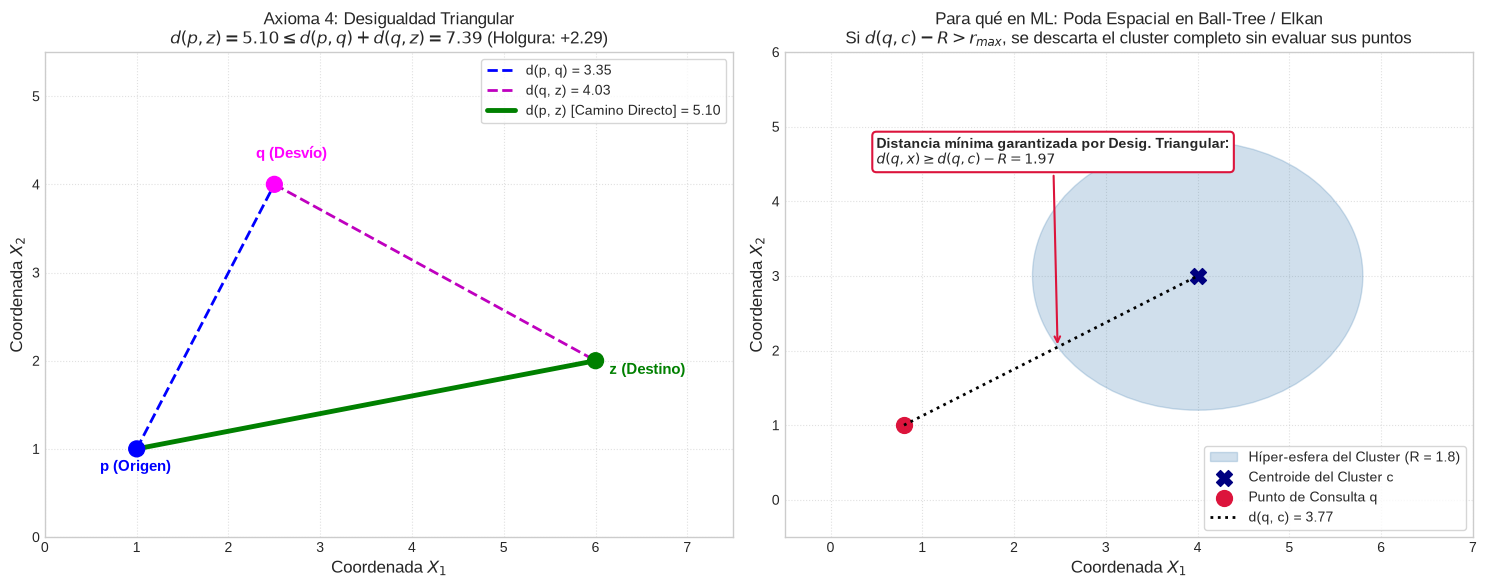

In [2]:
# =============================================================================
# VISUALIZACIÓN: AXIOMA 4 (DESIGUALDAD TRIANGULAR) & PODA EN BALL-TREES
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Geometría de la Desigualdad Triangular en R^2
p = np.array([1.0, 1.0])
q = np.array([2.5, 4.0])
z = np.array([6.0, 2.0])

d_pz = np.linalg.norm(p - z)
d_pq = np.linalg.norm(p - q)
d_qz = np.linalg.norm(q - z)

ax1.plot([p[0], q[0]], [p[1], q[1]], 'b--', lw=2, label=f'd(p, q) = {d_pq:.2f}')
ax1.plot([q[0], z[0]], [q[1], z[1]], 'm--', lw=2, label=f'd(q, z) = {d_qz:.2f}')
ax1.plot([p[0], z[0]], [p[1], z[1]], 'g-', lw=3.5, label=f'd(p, z) [Camino Directo] = {d_pz:.2f}')

ax1.scatter([p[0], q[0], z[0]], [p[1], q[1], z[1]], color=['blue', 'magenta', 'green'], s=130, zorder=5)
ax1.text(p[0]-0.4, p[1]-0.25, 'p (Origen)', fontsize=11, fontweight='bold', color='blue')
ax1.text(q[0]-0.2, q[1]+0.3, 'q (Desvío)', fontsize=11, fontweight='bold', color='magenta')
ax1.text(z[0]+0.15, z[1]-0.15, 'z (Destino)', fontsize=11, fontweight='bold', color='green')

holgura = (d_pq + d_qz) - d_pz
ax1.set_title(f"Axioma 4: Desigualdad Triangular\n$d(p, z) = {d_pz:.2f} \\leq d(p,q) + d(q,z) = {d_pq+d_qz:.2f}$ (Holgura: +{holgura:.2f})", fontsize=12)
ax1.set_xlabel("Coordenada $X_1$")
ax1.set_ylabel("Coordenada $X_2$")
ax1.legend(loc='upper right', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.set_xlim(0, 7.5)
ax1.set_ylim(0, 5.5)

# Subplot 2: Principio de Poda Métrica en Ball-Tree (Pruning)
center = np.array([4.0, 3.0])
radius = 1.8
query = np.array([0.8, 1.0])
d_qc = np.linalg.norm(query - center)

circle = plt.Circle(center, radius, color='steelblue', alpha=0.25, label=f'Híper-esfera del Cluster (R = {radius:.1f})')
ax2.add_patch(circle)
ax2.scatter([center[0]], [center[1]], color='navy', s=130, marker='X', label='Centroide del Cluster c')
ax2.scatter([query[0]], [query[1]], color='crimson', s=130, label='Punto de Consulta q')

ax2.plot([query[0], center[0]], [query[1], center[1]], 'k:', lw=2, label=f'd(q, c) = {d_qc:.2f}')

d_min = d_qc - radius
ax2.annotate(f"Distancia mínima garantizada por Desig. Triangular:\n$d(q, x) \\geq d(q, c) - R = {d_min:.2f}$",
             xy=(center[0] - radius * (center[0]-query[0])/d_qc, center[1] - radius * (center[1]-query[1])/d_qc),
             xytext=(0.5, 4.5),
             arrowprops=dict(arrowstyle="->", color='crimson', lw=1.5),
             fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="crimson", lw=1.5))

ax2.set_title("Para qué en ML: Poda Espacial en Ball-Tree / Elkan\nSi $d(q, c) - R > r_{max}$, se descarta el cluster completo sin evaluar sus puntos", fontsize=12)
ax2.set_xlabel("Coordenada $X_1$")
ax2.set_ylabel("Coordenada $X_2$")
ax2.legend(loc='lower right', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.set_xlim(-0.5, 7.0)
ax2.set_ylim(-0.5, 6.0)

plt.tight_layout()
plt.show()


---

### Familias de Métricas de Distancia: Fórmulas Exhaustivas y Desglose Analítico

#### 1. Distancia Euclidiana (Norma $L_2$)
Es la longitud geométrica del segmento de recta directa que conecta dos puntos en el espacio euclidiano $\mathbb{R}^n$:
$$d_2(\mathbf{p}, \mathbf{q}) = \|\mathbf{p} - \mathbf{q}\|_2 = \sqrt{\sum_{i=1}^n (p_i - q_i)^2}$$

* **Desglose minucioso de términos:**
  * $\mathbf{p} = (p_1, p_2, \dots, p_n)^T, \mathbf{q} = (q_1, q_2, \dots, q_n)^T$: Observaciones representadas como vectores coordenados.
  * $p_i, q_i$: Magnitud de la característica $i$ para cada observación.
  * $(p_i - q_i)^2$: Discrepancia al cuadrado. **Sensibilidad cuadrática a outliers**: una anomalía en una sola variable domina la suma.
  * $\sum_{i=1}^n$: Agrega las discrepancias de todas las dimensiones.
  * $\sqrt{\cdot}$: Devuelve la métrica a la unidad lineal de las variables originales.
* **Propiedad geométrica:** Es **isotrópica** (invariante a rotaciones del sistema de coordenadas).

---

#### 2. Distancia Manhattan (Norma $L_1$ o Geometría del Taxista / City Block)
Suma de las longitudes de las diferencias absolutas proyectadas sobre los ejes ortogonales de una cuadrícula:
$$d_1(\mathbf{p}, \mathbf{q}) = \|\mathbf{p} - \mathbf{q}\|_1 = \sum_{i=1}^n |p_i - q_i|$$

* **Desglose minucioso de términos:**
  * $|p_i - q_i|$: Distancia absoluta en la dimensión $i$. Equivale a desplazarse por calles ortogonales sin atravesar diagonales.
  * $\sum_{i=1}^n$: Suma lineal no cuadrática.
* **Ventaja analítica en ML:** **Robustez frente a outliers**. A diferencia de $L_2$, los valores extremos reciben una penalización proporcional y no exponencial. En espacios de alta dimensionalidad, $L_1$ sufre en menor medida el fenómeno de concentración de distancias (*Curse of Dimensionality*).

---

#### 3. Distancia Minkowski (Norma $L_p$ Generalizada)
Unificación paramétrica que define la familia completa de normas inducidas en espacios vectoriales normados:
$$d_p(\mathbf{p}, \mathbf{q}) = \|\mathbf{p} - \mathbf{q}\|_p = \left( \sum_{i=1}^n |p_i - q_i|^p \right)^{1/p}, \quad p \ge 1$$

* **Casos notables según el parámetro $p$:**
  * $p = 1$: Se reduce exactamente a la Distancia Manhattan ($L_1$).
  * $p = 2$: Se reduce exactamente a la Distancia Euclidiana ($L_2$).
  * $p \to \infty$: Converge a la Distancia de Chebyshev ($L_\infty$): $d_\infty(\mathbf{p}, \mathbf{q}) = \max_{1 \le i \le n} |p_i - q_i|$.
* **¿Por qué se exige $p \ge 1$? (Fundamento de Convexidad):**
  Para que la desigualdad triangular se cumpla (mediante la desigualdad de Minkowski), la bola unitaria debe ser **convexa**. Si $p < 1$ (ej. $p=0.5$), la bola unitaria se vuelve cóncava ("en forma de estrella"), violando la desigualdad triangular y dejando de ser una norma y una métrica.

---

#### 4. Similitud Coseno vs. Distancia Angular
Evalúa la orientación direccional relativa entre dos vectores, ignorando deliberadamente su longitud física (magnitud):
$$\text{Sim}_{\cos}(\mathbf{p}, \mathbf{q}) = \frac{\mathbf{p} \cdot \mathbf{q}}{\|\mathbf{p}\|_2 \|\mathbf{q}\|_2} = \frac{\sum_{i=1}^n p_i q_i}{\sqrt{\sum_{i=1}^n p_i^2} \sqrt{\sum_{i=1}^n q_i^2}}$$

$$d_{\cos}(\mathbf{p}, \mathbf{q}) = 1 - \text{Sim}_{\cos}(\mathbf{p}, \mathbf{q})$$

* **Invariancia de escala:** Si duplicamos todos los valores de un vector ($\mathbf{q} = 2\mathbf{p}$), $\text{Sim}_{\cos}(\mathbf{p}, \mathbf{q}) = 1.0$ y $d_{\cos} = 0.0$.
* **Aplicación en ML:** Minería de texto (TF-IDF, Embeddings) y sistemas de recomendación, donde un documento largo y un resumen corto sobre el mismo tema deben considerarse equivalentes independientemente de la cantidad total de palabras.
* **Distancia Angular Formal (Métrica Estricta):**
  Para satisfacer formalmente la desigualdad triangular:
  $$d_{ang}(\mathbf{p}, \mathbf{q}) = \frac{\arccos(\text{Sim}_{\cos}(\mathbf{p}, \mathbf{q}))}{\pi} \in [0, 1]$$


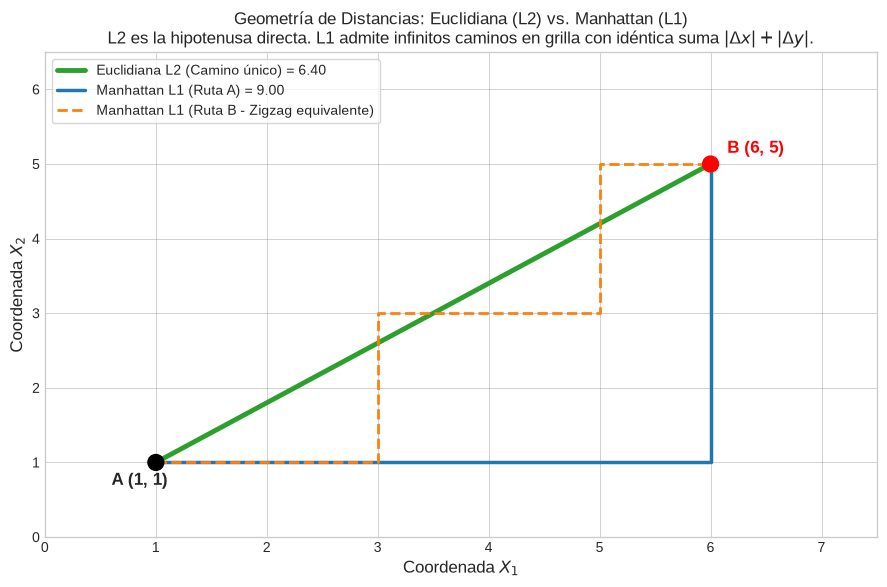

In [3]:
# =============================================================================
# VISUALIZACIÓN: GEOMETRÍA EN GRILLA (EUCLIDIANA L2 VS MANHATTAN L1)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6))

A = np.array([1, 1])
B = np.array([6, 5])

# Trayectoria Euclidiana L2 (hipotenusa única)
ax.plot([A[0], B[0]], [A[1], B[1]], color='#2ca02c', lw=3.5, label=f'Euclidiana L2 (Camino único) = {np.linalg.norm(A-B):.2f}')

# Trayectoria Manhattan L1 (Ruta A: eje X luego eje Y)
ax.plot([A[0], B[0], B[0]], [A[1], A[1], B[1]], color='#1f77b4', lw=2.5, linestyle='-', label=f'Manhattan L1 (Ruta A) = {np.sum(np.abs(A-B)):.2f}')

# Trayectoria Manhattan L1 (Ruta B: zigzag equivalente)
ax.plot([A[0], A[0]+2, A[0]+2, A[0]+4, A[0]+4, B[0]],
        [A[1], A[1], A[1]+2, A[1]+2, B[1], B[1]], color='#ff7f0e', lw=2, linestyle='--', label='Manhattan L1 (Ruta B - Zigzag equivalente)')

ax.scatter([A[0], B[0]], [A[1], B[1]], color=['black', 'red'], s=130, zorder=5)
ax.text(A[0]-0.4, A[1]-0.3, 'A (1, 1)', fontsize=12, fontweight='bold')
ax.text(B[0]+0.15, B[1]+0.15, 'B (6, 5)', fontsize=12, fontweight='bold', color='red')

ax.set_xticks(np.arange(0, 8, 1))
ax.set_yticks(np.arange(0, 7, 1))
ax.grid(True, which='both', color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

ax.set_title("Geometría de Distancias: Euclidiana (L2) vs. Manhattan (L1)\nL2 es la hipotenusa directa. L1 admite infinitos caminos en grilla con idéntica suma $|\\Delta x| + |\\Delta y|$.", fontsize=12)
ax.set_xlabel("Coordenada $X_1$")
ax.set_ylabel("Coordenada $X_2$")
ax.legend(loc='upper left', frameon=True)
ax.set_xlim(0, 7.5)
ax.set_ylim(0, 6.5)

plt.tight_layout()
plt.show()


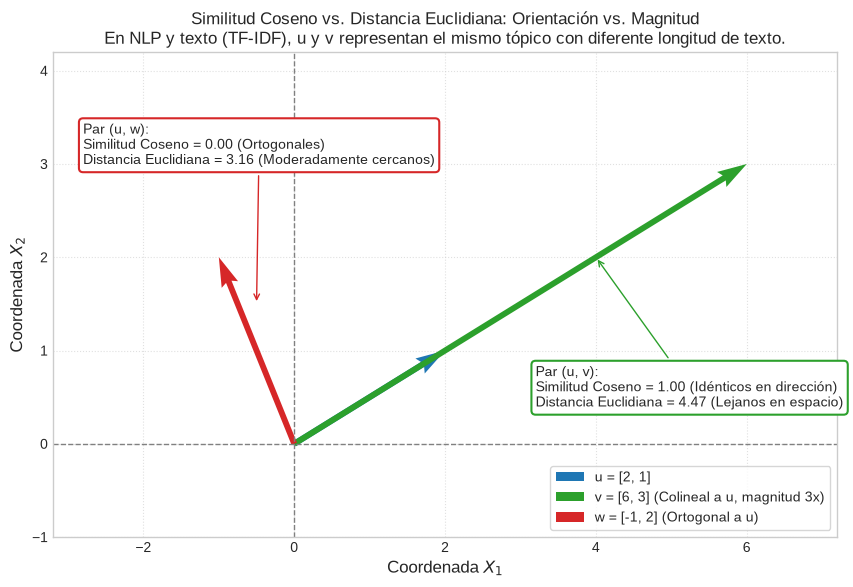

In [4]:
# =============================================================================
# VISUALIZACIÓN: SIMILITUD COSENO VS DISTANCIA EUCLIDIANA (ÁNGULO VS MAGNITUD)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6))

u = np.array([2.0, 1.0])
v = np.array([6.0, 3.0])  # Colineal a u, magnitud 3x
w = np.array([-1.0, 2.0]) # Ortogonal a u

ax.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1, color='#1f77b4', lw=2.5, label='u = [2, 1]')
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='#2ca02c', lw=2.5, label='v = [6, 3] (Colineal a u, magnitud 3x)')
ax.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='#d62728', lw=2.5, label='w = [-1, 2] (Ortogonal a u)')

cos_uv = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
d_euc_uv = np.linalg.norm(u - v)

cos_uw = np.dot(u, w) / (np.linalg.norm(u) * np.linalg.norm(w))
d_euc_uw = np.linalg.norm(u - w)

ax.annotate(f"Par (u, v):\nSimilitud Coseno = {cos_uv:.2f} (Idénticos en dirección)\nDistancia Euclidiana = {d_euc_uv:.2f} (Lejanos en espacio)",
            xy=(4, 2), xytext=(3.2, 0.4),
            arrowprops=dict(arrowstyle="->", color='#2ca02c'),
            fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#2ca02c", lw=1.5))

ax.annotate(f"Par (u, w):\nSimilitud Coseno = {cos_uw:.2f} (Ortogonales)\nDistancia Euclidiana = {d_euc_uw:.2f} (Moderadamente cercanos)",
            xy=(-0.5, 1.5), xytext=(-2.8, 3.0),
            arrowprops=dict(arrowstyle="->", color='#d62728'),
            fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d62728", lw=1.5))

ax.axhline(0, color='gray', lw=1, linestyle='--')
ax.axvline(0, color='gray', lw=1, linestyle='--')
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(-3.2, 7.2)
ax.set_ylim(-1.0, 4.2)
ax.set_xlabel("Coordenada $X_1$")
ax.set_ylabel("Coordenada $X_2$")
ax.set_title("Similitud Coseno vs. Distancia Euclidiana: Orientación vs. Magnitud\nEn NLP y texto (TF-IDF), u y v representan el mismo tópico con diferente longitud de texto.", fontsize=12)
ax.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()


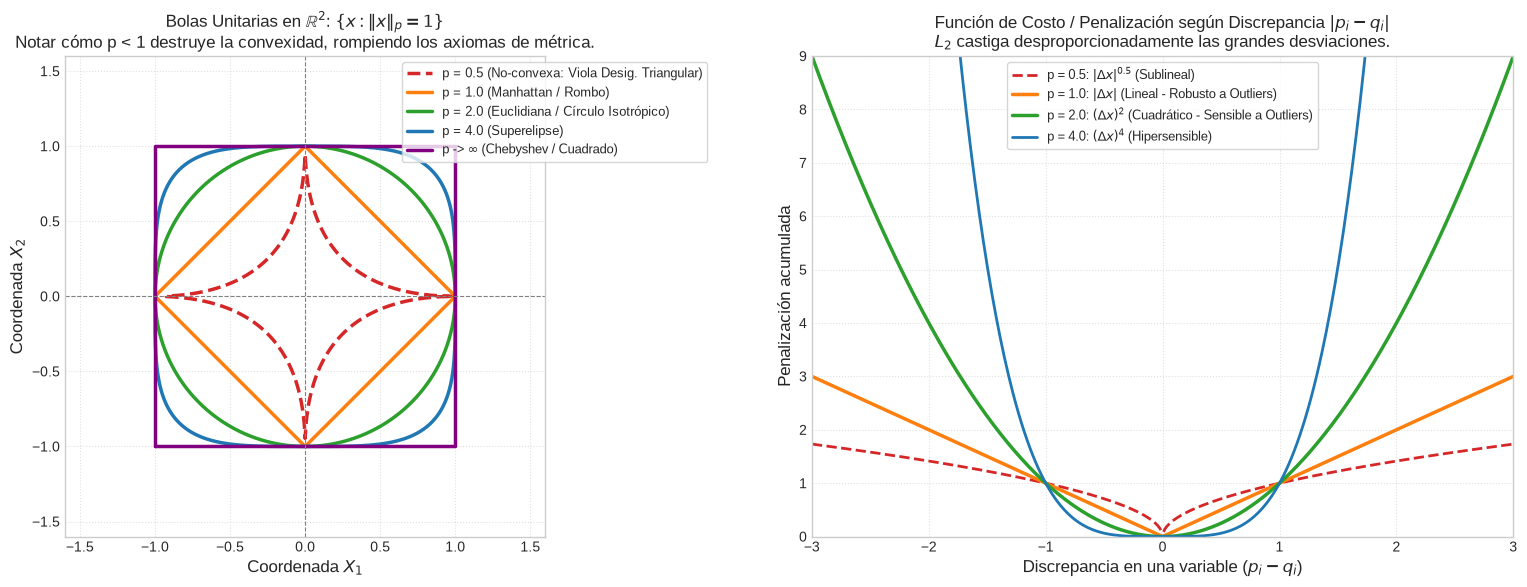

In [5]:
# =============================================================================
# VISUALIZACIÓN: BOLAS UNITARIAS (Lp) Y PERFIL DE PENALIZACIÓN DE DISCREPANCIAS
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Bolas unitarias en R^2
theta = np.linspace(0, 2*np.pi, 2000)

p_values = [0.5, 1.0, 2.0, 4.0]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
labels = [
    'p = 0.5 (No-convexa: Viola Desig. Triangular)',
    'p = 1.0 (Manhattan / Rombo)',
    'p = 2.0 (Euclidiana / Círculo Isotrópico)',
    'p = 4.0 (Superelipse)'
]

for p_val, col, lab in zip(p_values, colors, labels):
    r = (np.abs(np.cos(theta))**p_val + np.abs(np.sin(theta))**p_val)**(-1.0 / p_val)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    ls = '--' if p_val < 1.0 else '-'
    ax1.plot(x, y, color=col, lw=2.5, linestyle=ls, label=lab)

# Chebyshev p -> inf (cuadrado)
sq_x = [-1, 1, 1, -1, -1]
sq_y = [-1, -1, 1, 1, -1]
ax1.plot(sq_x, sq_y, color='purple', lw=2.5, label='p -> $\\infty$ (Chebyshev / Cuadrado)')

ax1.axhline(0, color='gray', lw=0.8, linestyle='--')
ax1.axvline(0, color='gray', lw=0.8, linestyle='--')
ax1.set_aspect('equal')
ax1.set_xlim(-1.6, 1.6)
ax1.set_ylim(-1.6, 1.6)
ax1.set_title("Bolas Unitarias en $\\mathbb{R}^2$: $\\{x : \\|x\\|_p = 1\\}$\nNotar cómo p < 1 destruye la convexidad, rompiendo los axiomas de métrica.", fontsize=12)
ax1.set_xlabel("Coordenada $X_1$")
ax1.set_ylabel("Coordenada $X_2$")
ax1.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0), frameon=True, fontsize=9)
ax1.grid(True, linestyle=':', alpha=0.6)

# Panel 2: Perfil de penalización de discrepancias
diffs = np.linspace(-3, 3, 500)
ax2.plot(diffs, np.abs(diffs)**0.5, color='#d62728', lw=2, linestyle='--', label='p = 0.5: $|\\Delta x|^{0.5}$ (Sublineal)')
ax2.plot(diffs, np.abs(diffs), color='#ff7f0e', lw=2.5, label='p = 1.0: $|\\Delta x|$ (Lineal - Robusto a Outliers)')
ax2.plot(diffs, diffs**2, color='#2ca02c', lw=2.5, label='p = 2.0: $(\\Delta x)^2$ (Cuadrático - Sensible a Outliers)')
ax2.plot(diffs, np.abs(diffs)**4, color='#1f77b4', lw=2, label='p = 4.0: $(\\Delta x)^4$ (Hipersensible)')

ax2.set_ylim(0, 9)
ax2.set_xlim(-3, 3)
ax2.set_title("Función de Costo / Penalización según Discrepancia $|p_i - q_i|$\n$L_2$ castiga desproporcionadamente las grandes desviaciones.", fontsize=12)
ax2.set_xlabel("Discrepancia en una variable ($p_i - q_i$)")
ax2.set_ylabel("Penalización acumulada")
ax2.legend(loc='upper center', frameon=True, fontsize=9)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


<a id="13-implementacion-vectorizada-numpy"></a>
### 1.3 Implementación Vectorizada Manual en NumPy (From Scratch)
A continuación implementamos cada métrica de distancia de forma manual y vectorizada con NumPy, incluyendo el cálculo matricial pairwise entre dos conjuntos de puntos mediante broadcasting.


In [6]:
# =============================================================================
# IMPLEMENTACIÓN VECTORIZADA MANUAL DE MÉTRICAS DE DISTANCIA
# =============================================================================

def dist_euclidiana_manual(p: np.ndarray, q: np.ndarray) -> float:
    """Calcula la distancia Euclidiana (L2) entre dos vectores p y q."""
    diff = np.asarray(p, dtype=float) - np.asarray(q, dtype=float)
    return float(np.sqrt(np.sum(diff ** 2)))


def dist_manhattan_manual(p: np.ndarray, q: np.ndarray) -> float:
    """Calcula la distancia Manhattan (L1) entre dos vectores p y q."""
    diff = np.asarray(p, dtype=float) - np.asarray(q, dtype=float)
    return float(np.sum(np.abs(diff)))


def dist_minkowski_manual(p: np.ndarray, q: np.ndarray, p_order: float = 3.0) -> float:
    """Calcula la distancia Minkowski Lp generalizada entre dos vectores p y q."""
    if p_order < 1.0:
        raise ValueError("El parámetro de orden p debe ser mayor o igual a 1.0.")
    diff = np.asarray(p, dtype=float) - np.asarray(q, dtype=float)
    return float(np.sum(np.abs(diff) ** p_order) ** (1.0 / p_order))


def dist_coseno_manual(p: np.ndarray, q: np.ndarray) -> float:
    """Calcula la distancia Coseno (1 - cos_sim) entre dos vectores p y q."""
    p_arr = np.asarray(p, dtype=float)
    q_arr = np.asarray(q, dtype=float)
    norm_p = np.linalg.norm(p_arr)
    norm_q = np.linalg.norm(q_arr)
    if norm_p == 0 or norm_q == 0:
        raise ZeroDivisionError("No es posible calcular similitud coseno con vectores de magnitud cero.")
    similitud = np.dot(p_arr, q_arr) / (norm_p * norm_q)
    # Acotar numéricamente al rango [-1.0, 1.0] para mitigar errores de redondeo float
    similitud_clipped = np.clip(similitud, -1.0, 1.0)
    return float(1.0 - similitud_clipped)


def dist_angular_manual(p: np.ndarray, q: np.ndarray) -> float:
    """
    Calcula la Distancia Angular normalizada en [0, 1].
    A diferencia de la distancia coseno ingenua (1 - cos_sim), la distancia angular
    satisface rigurosamente la desigualdad triangular, siendo una métrica formal idónea para Ball-Trees.
    """
    p_arr = np.asarray(p, dtype=float)
    q_arr = np.asarray(q, dtype=float)
    norm_p = np.linalg.norm(p_arr)
    norm_q = np.linalg.norm(q_arr)
    if norm_p == 0 or norm_q == 0:
        raise ZeroDivisionError("No es posible calcular distancia angular con vectores de magnitud cero.")
    similitud = np.clip(np.dot(p_arr, q_arr) / (norm_p * norm_q), -1.0, 1.0)
    return float(np.arccos(similitud) / np.pi)


def matriz_distancias_pairwise_manual(X: np.ndarray, Y: np.ndarray = None, metric: str = 'euclidean', p_order: float = 2.0) -> np.ndarray:
    """
    Calcula la matriz de distancias entre todas las filas de X e Y de forma vectorizada (broadcasting).
    Si Y es None, se calcula la matriz cuadrada de distancias entre las filas de X.
    """
    X_arr = np.asarray(X, dtype=float)
    Y_arr = X_arr if Y is None else np.asarray(Y, dtype=float)
    
    # Broadcasting tridimensional: X[:, None, :] tiene forma (M, 1, D) y Y[None, :, :] tiene (1, N, D)
    diff = X_arr[:, np.newaxis, :] - Y_arr[np.newaxis, :, :]  # Forma resultante: (M, N, D)
    
    if metric == 'euclidean':
        return np.sqrt(np.sum(diff ** 2, axis=2))
    elif metric == 'manhattan':
        return np.sum(np.abs(diff), axis=2)
    elif metric == 'minkowski':
        return np.sum(np.abs(diff) ** p_order, axis=2) ** (1.0 / p_order)
    elif metric == 'cosine':
        dot_product = np.dot(X_arr, Y_arr.T)
        norms_X = np.linalg.norm(X_arr, axis=1, keepdims=True)
        norms_Y = np.linalg.norm(Y_arr, axis=1, keepdims=True)
        sim = dot_product / (norms_X * norms_Y.T)
        return 1.0 - np.clip(sim, -1.0, 1.0)
    elif metric == 'angular':
        dot_product = np.dot(X_arr, Y_arr.T)
        norms_X = np.linalg.norm(X_arr, axis=1, keepdims=True)
        norms_Y = np.linalg.norm(Y_arr, axis=1, keepdims=True)
        sim = np.clip(dot_product / (norms_X * norms_Y.T), -1.0, 1.0)
        return np.arccos(sim) / np.pi
    else:
        raise ValueError(f"Métrica desconocida: {metric}")

print("✅ Funciones vectorizadas de distancias compiladas correctamente en memoria.")


✅ Funciones vectorizadas de distancias compiladas correctamente en memoria.


<a id="14-validacion-scipy-sklearn"></a>
### 1.4 Test con Datos Sintéticos y Validación Cruzada (SciPy & Scikit-Learn)
Validamos la precisión de nuestras implementaciones manuales contra las funciones estándar de SciPy (`scipy.spatial.distance`) y Scikit-Learn (`pairwise_distances`), verificando discrepancias numéricas mediante aserciones con tolerancia estricta ($< 10^{-12}$).


In [7]:
# =============================================================================
# VALIDACIÓN CRUZADA CONTRA SCIPY Y SCIKIT-LEARN
# =============================================================================
from scipy.spatial.distance import (
    euclidean as scipy_euclidean,
    cityblock as scipy_cityblock,
    minkowski as scipy_minkowski,
    cosine as scipy_cosine
)
from sklearn.metrics.pairwise import pairwise_distances

# Generación de dos observaciones sintéticas en 5 dimensiones
p_sample = np.array([2.5, 0.0, 4.8, 1.2, 7.3])
q_sample = np.array([1.1, 3.2, 2.4, 1.8, 5.0])

# Cómputo con implementaciones manuales
d_euc_man = dist_euclidiana_manual(p_sample, q_sample)
d_man_man = dist_manhattan_manual(p_sample, q_sample)
d_min_man = dist_minkowski_manual(p_sample, q_sample, p_order=3.0)
d_cos_man = dist_coseno_manual(p_sample, q_sample)
d_ang_man = dist_angular_manual(p_sample, q_sample)

# Cómputo con SciPy oficial
d_euc_sci = scipy_euclidean(p_sample, q_sample)
d_man_sci = scipy_cityblock(p_sample, q_sample)
d_min_sci = scipy_minkowski(p_sample, q_sample, p=3.0)
d_cos_sci = scipy_cosine(p_sample, q_sample)

# Validación de exactitud numérica con tolerancia ultra-estricta (1e-12)
assert np.isclose(d_euc_man, d_euc_sci, atol=1e-12), "Discrepancia en Distancia Euclidiana"
assert np.isclose(d_man_man, d_man_sci, atol=1e-12), "Discrepancia en Distancia Manhattan"
assert np.isclose(d_min_man, d_min_sci, atol=1e-12), "Discrepancia en Distancia Minkowski"
assert np.isclose(d_cos_man, d_cos_sci, atol=1e-12), "Discrepancia en Distancia Coseno"

# Tabla comparativa de resultados
df_dist_test = pd.DataFrame({
    'Métrica': ['Euclidiana (L2)', 'Manhattan (L1)', 'Minkowski (p=3)', 'Coseno (1 - cos)'],
    'Manual NumPy': [d_euc_man, d_man_man, d_min_man, d_cos_man],
    'SciPy Oficial': [d_euc_sci, d_man_sci, d_min_sci, d_cos_sci],
    'Diferencia Absoluta': [
        abs(d_euc_man - d_euc_sci),
        abs(d_man_man - d_man_sci),
        abs(d_min_man - d_min_sci),
        abs(d_cos_man - d_cos_sci)
    ]
})
print("📊 Tabla de Validación de Distancias Vector vs Vector:")
print(df_dist_test.to_string(index=False))

# Test matricial Pairwise: Matriz de 4 muestras x 3 dimensiones
X_test = np.array([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
    [7.0, 8.0, 9.0],
    [1.5, 3.5, 5.5]
])

mat_manual = matriz_distancias_pairwise_manual(X_test, metric='euclidean')
mat_sklearn = pairwise_distances(X_test, metric='euclidean')

assert np.allclose(mat_manual, mat_sklearn, atol=1e-12), "Discrepancia en matriz pairwise de Scikit-Learn"
print("\n✅ Validación Pairwise Exitosa: Error máximo frente a Scikit-Learn =", np.max(np.abs(mat_manual - mat_sklearn)))


📊 Tabla de Validación de Distancias Vector vs Vector:
         Métrica  Manual NumPy  SciPy Oficial  Diferencia Absoluta
 Euclidiana (L2)      4.859012       4.859012         0.000000e+00
  Manhattan (L1)      9.900000       9.900000         0.000000e+00
 Minkowski (p=3)      3.951903       3.951903         0.000000e+00
Coseno (1 - cos)      0.143468       0.143468         1.110223e-16

✅ Validación Pairwise Exitosa: Error máximo frente a Scikit-Learn = 0.0


<a id="clase-2"></a>
# 2. Clase 2: EDA, Preprocesamiento, Escalamiento & KNN

<a id="21-estandarizacion-vs-normalizacion"></a>
## 2.1 Estandarización Z-score vs. Normalización Min-Max: El Por Qué y Para Qué del Escalamiento

### ¿Por qué es obligatorio escalar en modelos basados en distancias?
En algoritmos geométricos ($k$-NN, $K$-Means, SVM, PCA), las distancias euclidianas no poseen inteligencia semántica sobre las unidades físicas de las características. Una variable como *Ingreso Anual* con valores en $[0, 100000]$ tendrá diferencias numéricas de miles, mientras que una variable como *Edad* con valores en $[20, 65]$ tendrá diferencias de decenas.

Si calculamos la distancia euclidiana:
$$d(\mathbf{p}, \mathbf{q}) = \sqrt{(p_{\text{Ingreso}} - q_{\text{Ingreso}})^2 + (p_{\text{Edad}} - q_{\text{Edad}})^2}$$
el término del ingreso dominará por un factor de $10^6$ la suma cuadrática. Las híper-esferas de vecindad de $k$-NN se transforman en **elipsoides extremadamente achatados**, haciendo que el algoritmo decida la clasificación basándose **únicamente en la variable con mayor escala numérica**, ignorando a las demás por completo.

---

### 1. Estandarización Z-score (Centrado y Varianza Unitaria)
Proyecta los datos hacia una distribución con media centrada en cero y desviación estándar unitaria:
$$z = \frac{x - \mu}{\sigma}$$

* **Desglose de términos:**
  * $x$: Valor empírico original de la observación.
  * $\mu = \frac{1}{N} \sum_{i=1}^N x_i$: Media aritmética muestral (centro de masa).
  * $\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^N (x_i - \mu)^2}$: Desviación estándar muestral (escala de dispersión).
  * Propiedades: $\mathbb{E}[Z] = 0$, $\text{Var}(Z) = 1$.
* **¿Por qué divide por $\sigma$?**: Cada unidad de $z$ representa exactamente "una desviación estándar de distancia respecto a la media". Esferiza el espacio métrico (**isotropía**), permitiendo que todas las características contribuyan con varianza equivalente al cálculo de distancias.
* **Comportamiento ante Outliers**: No acota el rango a un intervalo cerrado. Conserva la distancia relativa de los valores atípicos sin destruir la resolución de las muestras centrales.

---

### 2. Normalización Min-Max (Reescalamiento Acotado)
Realiza una transformación afín estricta mapeando los datos al intervalo acotado $[a, b]$, convencionalmente $[0, 1]$:
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

* **Desglose de términos:**
  * $x_{\min} = \min(X), x_{\max} = \max(X)$: Valores extremos inferior y superior observados en la muestra.
  * $x_{\max} - x_{\min}$: Rango dinámico total de la característica.
* **¿Para qué sirve?**: Imprescindible en algoritmos que exigen entradas acotadas en $[0, 1]$, tales como Redes Neuronales con funciones de activación sigmoide o algoritmos de procesamiento de imágenes.
* **El Peligro Crítico ante Outliers (Colapso de Resolución)**:
  Si una característica oscila típicamente en $[10, 50]$ pero existe un único outlier con valor $1000$, el nuevo rango dinámico será $1000 - 10 = 990$. Todas las muestras legítimas se comprimirán en la diminuta franja $[0.0, 0.04]$, **destruyendo la señal informativa** del $99.9\%$ de los datos.


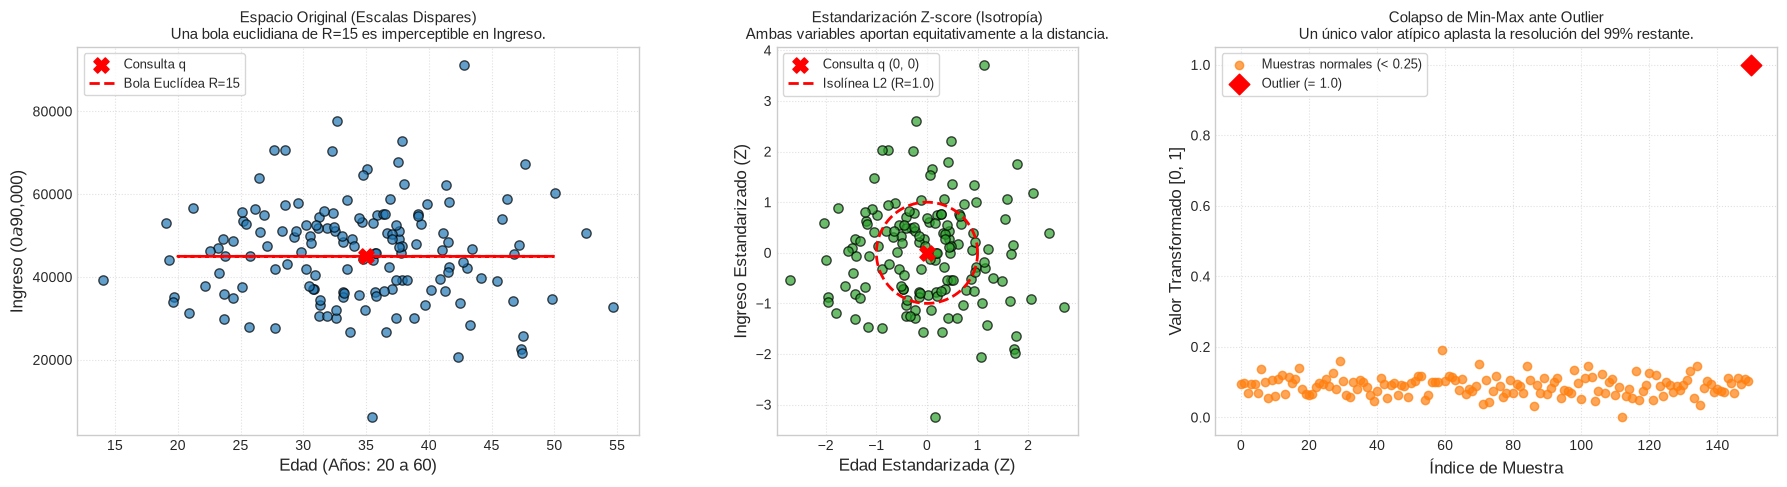

In [8]:
# =============================================================================
# VISUALIZACIÓN: DISTORSIÓN DE DISTANCIAS Y EFECTO DE OUTLIERS EN ESCALAMIENTO
# =============================================================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

np.random.seed(42)
edad = np.random.normal(loc=35, scale=8, size=150)
ingreso = np.random.normal(loc=45000, scale=12000, size=150)

# Panel 1: Espacio Original No Escalado
ax1.scatter(edad, ingreso, color='#1f77b4', alpha=0.7, edgecolors='k', s=45)
q_edad, q_ing = 35, 45000
ax1.scatter([q_edad], [q_ing], color='red', s=120, marker='X', zorder=5, label='Consulta q')

t = np.linspace(0, 2*np.pi, 200)
ax1.plot(q_edad + 15*np.cos(t), q_ing + 15*np.sin(t), 'r--', lw=2, label='Bola Euclídea R=15')
ax1.set_title("Espacio Original (Escalas Dispares)\nUna bola euclidiana de R=15 es imperceptible en Ingreso.", fontsize=11)
ax1.set_xlabel("Edad (Años: 20 a 60)")
ax1.set_ylabel("Ingreso ($0 a $90,000)")
ax1.legend(loc='upper left', frameon=True, fontsize=9)
ax1.grid(True, linestyle=':', alpha=0.6)

# Panel 2: Espacio Z-Score Esferizado
edad_z = (edad - edad.mean()) / edad.std()
ing_z = (ingreso - ingreso.mean()) / ingreso.std()
ax2.scatter(edad_z, ing_z, color='#2ca02c', alpha=0.7, edgecolors='k', s=45)
ax2.scatter([0], [0], color='red', s=120, marker='X', zorder=5, label='Consulta q (0, 0)')
ax2.plot(np.cos(t), np.sin(t), 'r--', lw=2, label='Isolínea L2 (R=1.0)')
ax2.set_title("Estandarización Z-score (Isotropía)\nAmbas variables aportan equitativamente a la distancia.", fontsize=11)
ax2.set_xlabel("Edad Estandarizada (Z)")
ax2.set_ylabel("Ingreso Estandarizado (Z)")
ax2.set_aspect('equal')
ax2.legend(loc='upper left', frameon=True, fontsize=9)
ax2.grid(True, linestyle=':', alpha=0.6)

# Panel 3: Colapso de Min-Max ante Outlier
ing_con_outlier = np.append(ingreso, [450000]) # Outlier 10x
ing_minmax = (ing_con_outlier - ing_con_outlier.min()) / (ing_con_outlier.max() - ing_con_outlier.min())

ax3.scatter(range(150), ing_minmax[:150], color='#ff7f0e', alpha=0.7, label='Muestras normales (< 0.25)')
ax3.scatter([150], [ing_minmax[-1]], color='red', s=110, marker='D', label='Outlier (= 1.0)')
ax3.set_title("Colapso de Min-Max ante Outlier\nUn único valor atípico aplasta la resolución del 99% restante.", fontsize=11)
ax3.set_xlabel("Índice de Muestra")
ax3.set_ylabel("Valor Transformado [0, 1]")
ax3.legend(loc='upper left', frameon=True, fontsize=9)
ax3.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


---

<a id="22-data-leakage"></a>
## 2.2 El Peligro Crítico de Data Leakage (Fuga de Datos)

El **Data Leakage** ocurre cuando información del conjunto de prueba (o del futuro operacional) se filtra inadvertidamente en el entrenamiento o preprocesamiento del modelo.

### 🚨 La Regla de Oro del Aprendizaje Automático
> **Todo parámetro de preprocesamiento (medias $\mu$, desviaciones $\sigma$, medianas de imputación, frecuencias de categorías, selectores de variables) DEBE aprenderse estrictamente con el conjunto de entrenamiento (`X_train`) usando `.fit()` o `.fit_transform()`. El conjunto de prueba (`X_test`) debe tratarse como datos no vistos en producción y transformarse EXCLUSIVAMENTE con `.transform()`.**

#### ¿Por qué es un error fatal fit_transform sobre todo el dataset?
Si calculamos la media o el escalador antes de dividir en Train/Test:
1. Las medias y desviaciones de `X_train` estarán contaminadas con la varianza de `X_test`.
2. Las métricas de evaluación en Test serán **artificialmente optimistas y engañosas**.
3. En producción real (donde los nuevos clientes o transacciones no estuvieron en el histórico), el modelo experimentará una degradación abrupta de rendimiento.


<a id="23-preprocesamiento-tabular"></a>
### 2.3 Preprocesamiento Tabular y Limpieza de Datos (Estilo Titanic)
Generamos un conjunto de datos sintético realista con valores numéricos y categóricos, incluyendo datos faltantes intencionales. Luego aplicamos la regla de oro: partición previa, imputación sin fuga de datos, One-Hot Encoding y estandarización Z-score con `StandardScaler`.


In [9]:
# =============================================================================
# PREPROCESAMIENTO TABULAR ESTILO TITANIC (SIN DATA LEAKAGE)
# =============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Generación sintética representativa de un dataset de 600 pasajeros (estilo Titanic)
np.random.seed(RANDOM_STATE)
n_samples = 600

edades = np.random.normal(loc=30, scale=14, size=n_samples)
edades = np.clip(edades, 1, 80)
# Inyectar valores nulos intencionales (12% de registros faltantes en Age)
mask_nulos = np.random.rand(n_samples) < 0.12
edades[mask_nulos] = np.nan

tarifas = np.random.exponential(scale=35, size=n_samples) + 7.5
parientes = np.random.poisson(lam=0.8, size=n_samples)
genero = np.random.choice(['male', 'female'], size=n_samples, p=[0.65, 0.35])
pclass = np.random.choice([1, 2, 3], size=n_samples, p=[0.25, 0.25, 0.50])
puerto = np.random.choice(['S', 'C', 'Q', None], size=n_samples, p=[0.70, 0.20, 0.08, 0.02])

# Probabilidad de supervivencia condicionada
log_odds = (
    -1.2 
    + 1.8 * (genero == 'female') 
    + 1.0 * (pclass == 1) 
    - 0.8 * (pclass == 3) 
    + 0.015 * tarifas 
    - 0.02 * np.nan_to_num(edades, nan=30)
)
prob_supervivencia = 1.0 / (1.0 + np.exp(-log_odds))
sobrevivio = (np.random.rand(n_samples) < prob_supervivencia).astype(int)

df_titanic = pd.DataFrame({
    'Age': edades,
    'Fare': tarifas,
    'SibSp': parientes,
    'Sex': genero,
    'Pclass': pclass,
    'Embarked': puerto,
    'Survived': sobrevivio
})

print("📋 Primeros 5 registros del dataset sintético:")
print(df_titanic.head())
print("\n🔍 Diagnóstico de valores nulos:")
print(df_titanic.isnull().sum())

# -----------------------------------------------------------------------------
# PARTICIÓN TRAIN/TEST ANTES DE CUALQUIER IMPUTACIÓN O TRANSFORMACIÓN
# -----------------------------------------------------------------------------
X = df_titanic.drop(columns=['Survived'])
y = df_titanic['Survived']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Imputación CORRECTA sin Data Leakage:
# 1. Mediana de edad calculada ÚNICAMENTE en train
mediana_edad_train = X_train_raw['Age'].median()
X_train_clean = X_train_raw.copy()
X_test_clean = X_test_raw.copy()
X_train_clean['Age'] = X_train_clean['Age'].fillna(mediana_edad_train)
X_test_clean['Age'] = X_test_clean['Age'].fillna(mediana_edad_train)

# 2. Moda de embarque calculada ÚNICAMENTE en train
moda_puerto_train = X_train_raw['Embarked'].mode()[0]
X_train_clean['Embarked'] = X_train_clean['Embarked'].fillna(moda_puerto_train)
X_test_clean['Embarked'] = X_test_clean['Embarked'].fillna(moda_puerto_train)

# 3. One-Hot Encoding consistente con drop_first=True para evitar colinealidad
X_train_encoded = pd.get_dummies(X_train_clean, columns=['Sex', 'Embarked', 'Pclass'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test_clean, columns=['Sex', 'Embarked', 'Pclass'], drop_first=True)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# 4. Estandarización Z-score respetando la regla fit en train y transform en test
num_cols = ['Age', 'Fare', 'SibSp']
scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_encoded[num_cols])

print(f"\n✅ Preprocesamiento completado con éxito.")
print(f"Train Shape: {X_train_scaled.shape} | Test Shape: {X_test_scaled.shape}")
print(f"Media Age Train estandarizada = {X_train_scaled['Age'].mean():.4f} | Std = {X_train_scaled['Age'].std():.4f}")
print(f"Media Age Test estandarizada  = {X_test_scaled['Age'].mean():.4f} | Std = {X_test_scaled['Age'].std():.4f}")


📋 Primeros 5 registros del dataset sintético:
         Age       Fare  SibSp     Sex  Pclass Embarked  Survived
0  36.953998  28.126806      0    male       1        S         1
1  28.064300  32.813045      0  female       1        S         1
2  39.067640  23.078149      2  female       1        S         1
3  51.322418  38.958747      1    male       2      NaN         1
4  26.721853  13.749505      1    male       3        S         0

🔍 Diagnóstico de valores nulos:
Age         75
Fare         0
SibSp        0
Sex          0
Pclass       0
Embarked    14
Survived     0
dtype: int64

✅ Preprocesamiento completado con éxito.
Train Shape: (450, 8) | Test Shape: (150, 8)
Media Age Train estandarizada = -0.0000 | Std = 1.0011
Media Age Test estandarizada  = -0.0508 | Std = 0.9579


<a id="24-knn-hiperparametro-k"></a>
### 2.4 Clasificación KNN y Análisis del Hiperparámetro K: Sesgo vs. Varianza

El algoritmo $K$-Nearest Neighbors clasifica una nueva observación asignándole la clase mayoritaria entre sus $K$ vecinos más cercanos en el espacio de entrenamiento:
$$\hat{y} = \arg\max_{c} \sum_{i \in \mathcal{N}_K(x)} \mathbb{I}(y_i = c)$$

#### ¿Por qué el valor de K controla la complejidad del modelo?
* **Caso $K = 1$ (Máxima Complejidad / Alta Varianza / Sobreajuste)**:
  La frontera de decisión coincide exactamente con las celdas del **diagrama de Voronoi** de las muestras. Cada punto individual, incluso el ruido o etiquetas erróneas, crea su propia "isla" de decisión. Error en Train $= 0$, pero muy mal desempeño en Test.
* **Caso $K$ equilibrado (ej. $K = 5 \text{ a } 15$)**:
  El promedio de votos amortigua el ruido muestral local y aproxima la verdadera distribución probabilística $P(Y \mid X)$.
* **Caso $K \to N$ (Mínima Complejidad / Alto Sesgo / Subajuste)**:
  La frontera pierde toda capacidad de discriminación local y predice ciegamente la clase mayoritaria de todo el dataset, sin importar la posición de la muestra.


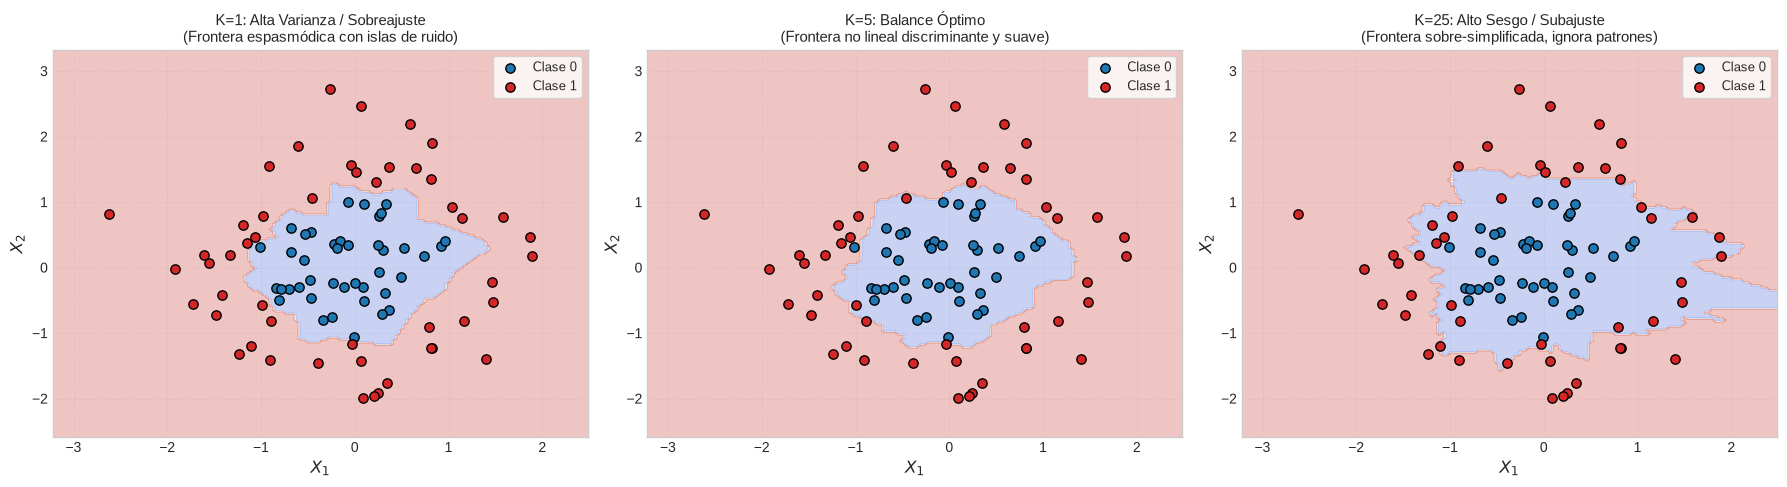

In [10]:
# =============================================================================
# VISUALIZACIÓN: SUPERFICIES DE DECISIÓN DE KNN EN 2D (SESGO VS VARIANZA)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

np.random.seed(42)
X_demo = np.random.randn(90, 2)
y_demo = (X_demo[:, 0]**2 + X_demo[:, 1]**2 > 1.2).astype(int)

x_min, x_max = X_demo[:, 0].min() - 0.6, X_demo[:, 0].max() + 0.6
y_min, y_max = X_demo[:, 1].min() - 0.6, X_demo[:, 1].max() + 0.6
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
grid_points = np.c_[xx.ravel(), yy.ravel()]

from sklearn.neighbors import KNeighborsClassifier

k_tests = [1, 5, 25]
titles = [
    "K=1: Alta Varianza / Sobreajuste\n(Frontera espasmódica con islas de ruido)",
    "K=5: Balance Óptimo\n(Frontera no lineal discriminante y suave)",
    "K=25: Alto Sesgo / Subajuste\n(Frontera sobre-simplificada, ignora patrones)"
]

for ax, k_val, tit in zip(axes, k_tests, titles):
    clf = KNeighborsClassifier(n_neighbors=k_val)
    clf.fit(X_demo, y_demo)
    Z = clf.predict(grid_points).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_demo[y_demo==0, 0], X_demo[y_demo==0, 1], color='#1f77b4', edgecolors='k', label='Clase 0', s=45)
    ax.scatter(X_demo[y_demo==1, 0], X_demo[y_demo==1, 1], color='#d62728', edgecolors='k', label='Clase 1', s=45)
    ax.set_title(tit, fontsize=11)
    ax.set_xlabel("$X_1$")
    ax.set_ylabel("$X_2$")
    ax.legend(loc='upper right', frameon=True, fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()


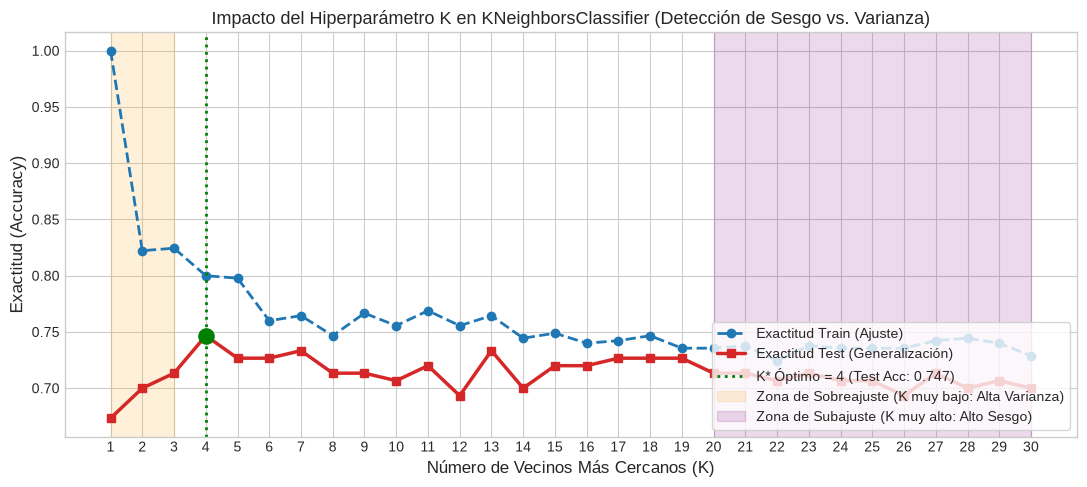

🎯 Conclusión del Experimento KNN:
Para K=1, la exactitud en Train es 1.0000 (memorización total), pero en Test cae a 0.6733.
El K óptimo es K=4 alcanzando una exactitud de generalización del 74.67%.


In [11]:
# =============================================================================
# CLASIFICACIÓN CON KNN Y BARRIDO DEL HIPERPARÁMETRO K
# =============================================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = list(range(1, 31))
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    
    y_pred_train = knn.predict(X_train_scaled)
    y_pred_test = knn.predict(X_test_scaled)
    
    train_accuracies.append(accuracy_score(y_train, y_pred_train))
    test_accuracies.append(accuracy_score(y_test, y_pred_test))

best_k = k_values[int(np.argmax(test_accuracies))]
best_test_acc = max(test_accuracies)

# Gráfico del impacto del hiperparámetro K
plt.figure(figsize=(11, 5))
plt.plot(k_values, train_accuracies, marker='o', label='Exactitud Train (Ajuste)', color='#1f77b4', linestyle='--')
plt.plot(k_values, test_accuracies, marker='s', label='Exactitud Test (Generalización)', color='#d62728', linewidth=2.5)

plt.axvline(x=best_k, color='green', linestyle=':', label=f'K* Óptimo = {best_k} (Test Acc: {best_test_acc:.3f})')
plt.scatter([best_k], [best_test_acc], color='green', s=120, zorder=5)

plt.axvspan(1, 3, alpha=0.15, color='orange', label='Zona de Sobreajuste (K muy bajo: Alta Varianza)')
plt.axvspan(20, 30, alpha=0.15, color='purple', label='Zona de Subajuste (K muy alto: Alto Sesgo)')

plt.title('Impacto del Hiperparámetro K en KNeighborsClassifier (Detección de Sesgo vs. Varianza)')
plt.xlabel('Número de Vecinos Más Cercanos (K)')
plt.ylabel('Exactitud (Accuracy)')
plt.xticks(k_values)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

print(f"🎯 Conclusión del Experimento KNN:")
print(f"Para K=1, la exactitud en Train es {train_accuracies[0]:.4f} (memorización total), pero en Test cae a {test_accuracies[0]:.4f}.")
print(f"El K óptimo es K={best_k} alcanzando una exactitud de generalización del {best_test_acc * 100:.2f}%.")


<a id="clase-3"></a>
# 3. Clase 3: Árboles de Decisión (ID3, CART) y Métricas de Pureza

<a id="31-metricas-pureza"></a>
## 3.1 Entropía de Shannon, Ganancia de Información y Gini: Fundamento y Sesgo Inductivo

Los árboles de decisión son modelos no paramétricos que dividen recursivamente el espacio de características en hiper-rectángulos ortogonales disjuntos. La calidad de una partición se mide mediante criterios matemáticos de **impureza**.

---

### 1. Entropía de Shannon (Algoritmo ID3 / C4.5)
Cuantifica la incertidumbre o nivel de desorden probabilístico de una partición de datos $S$:
$$H(S) = - \sum_{c=1}^C p_c \log_2(p_c)$$

* **Desglose de términos:**
  * $S$: Subconjunto o nodo de datos evaluado.
  * $C$: Número total de clases objetivo ($c \in \{1, 2, \dots, C\}$).
  * $p_c = \frac{|S_c|}{|S|}$: Proporción empírica de muestras en $S$ que pertenecen a la clase $c$.
  * $\log_2(p_c)$: Logaritmo en base 2 (unidades medidas en *bits* de información).
  * Convención matemática: $\lim_{p \to 0^+} p \log_2(p) = 0$.
  * Rango: $H(S) = 0$ cuando el nodo es **puro** (una sola clase). Máximo $H(S) = \log_2(C)$ cuando la distribución es uniforme.
* **¿Por qué logaritmo en base 2? (Fundamento de Información):**
  Satisface el principio de **aditividad informacional**: la incertidumbre conjunta de dos variables aleatorias independientes debe ser la suma de sus incertidumbres individuales ($H(X, Y) = H(X) + H(Y)$). Un evento con probabilidad $p=0.5$ aporta exactamente $1$ bit de sorpresa.

---

### 2. Ganancia de Información (Information Gain - ID3) y el Sesgo de Alta Cardinalidad
Mide la reducción esperada en la entropía al particionar el conjunto $S$ según un atributo candidato $A$:
$$IG(S, A) = H(S) - \sum_{v \in \text{Valores}(A)} \frac{|S_v|}{|S|} H(S_v)$$

* **Desglose de términos:**
  * $H(S)$: Entropía original del nodo padre antes de la partición.
  * $S_v$: Subconjunto de muestras donde el atributo $A$ toma el valor $v$.
  * $\frac{|S_v|}{|S|}$: Ponderación probabilística de la rama $v$.
  * $H(S_v)$: Entropía del nodo hijo resultante.
* **El Gotcha Crítico / Fallo de ID3:**
  Si una variable tiene **alta cardinalidad** (ej. número de DNI, ID de cliente, fecha exacta), dividirá el dataset en cientos de ramas con 1 sola muestra cada una. Como cada nodo hijo tendrá $H(S_v) = 0$, la Ganancia de Información será máxima ($IG = H(S)$). Sin embargo, el árbol no habrá aprendido ningún patrón: habrá memorizado los datos (**sobreajuste extremo**).
* **Solución de C4.5: Gain Ratio (Tasa de Ganancia):**
  Quinlan (1993) introdujo la penalización por información de división (**Split Information**):
  $$\text{SplitInfo}(S, A) = - \sum_{v} \frac{|S_v|}{|S|} \log_2\left(\frac{|S_v|}{|S|}\right), \quad \text{GainRatio}(S, A) = \frac{IG(S, A)}{\text{SplitInfo}(S, A)}$$
  Penaliza a los atributos que fragmentan los datos en muchas ramas artificiales.

---

### 3. Índice de Impureza de Gini (Algoritmo CART)
Representa la probabilidad de clasificar erróneamente un elemento elegido al azar si se le asignara una etiqueta según la distribución empírica del nodo:
$$Gini(S) = 1 - \sum_{c=1}^C p_c^2$$

* **Desglose de términos:**
  * $p_c^2$: Probabilidad de que dos elementos independientes elegidos de $S$ pertenezcan a la misma clase $c$.
  * Para clasificación binaria ($p$ y $1-p$): $Gini(S) = 2p(1-p)$.
  * Rango binario: Mínimo $0.0$ (nodo puro), Máximo $0.5$ (máxima impureza, $50\% - 50\%$).
* **¿Por qué CART utiliza Gini en lugar de Entropía? (Ventaja Computacional):**
  Gini es una aproximación cuadrática de Taylor de la función de entropía ($-\ln(p) \approx 1 - p$). **Evita evaluar logaritmos trascendentales en CPU**, lo que acelera exponencialmente el tiempo de entrenamiento al probar miles de cortes continuos en datasets industriales, manteniendo una calidad de split matemáticamente idéntica.

---

### 4. Sesgo Inductivo de los Árboles: Geometría de Partición Ortogonal
Los árboles de decisión basados en CART generan divisiones estrictamente **paralelas a los ejes coordenados** ($X_j \le \theta$).
* Si la frontera real es ortogonal, el árbol la captura de forma óptima con pocos niveles.
* Si la frontera verdadera es diagonal o no lineal (ej. $X_1 + X_2 > c$), el árbol se ve obligado a aproximarla mediante una **secuencia escalonada (efecto escalera / staircase effect)**, requiriendo gran profundidad y facilitando el sobreajuste.


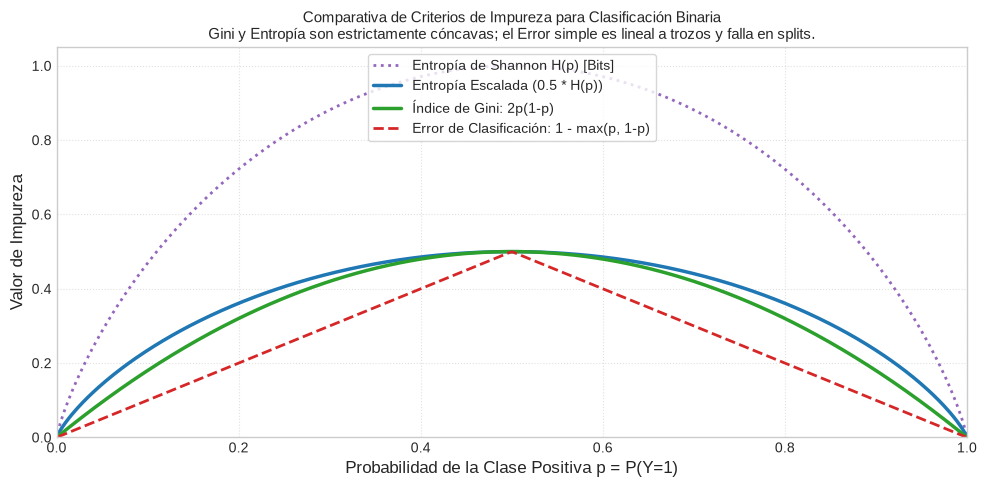

In [12]:
# =============================================================================
# VISUALIZACIÓN: COMPARATIVA DE CRITERIOS DE IMPUREZA BINARIA
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5))

p = np.linspace(0.001, 0.999, 500)
entropia = - (p * np.log2(p) + (1 - p) * np.log2(1 - p))
entropia_escalada = 0.5 * entropia
gini = 2 * p * (1 - p)
error_clasif = 1 - np.maximum(p, 1 - p)

ax.plot(p, entropia, color='#9467bd', lw=2, linestyle=':', label='Entropía de Shannon H(p) [Bits]')
ax.plot(p, entropia_escalada, color='#1f77b4', lw=2.5, label='Entropía Escalada (0.5 * H(p))')
ax.plot(p, gini, color='#2ca02c', lw=2.5, label='Índice de Gini: 2p(1-p)')
ax.plot(p, error_clasif, color='#d62728', lw=2, linestyle='--', label='Error de Clasificación: 1 - max(p, 1-p)')

ax.set_title("Comparativa de Criterios de Impureza para Clasificación Binaria\nGini y Entropía son estrictamente cóncavas; el Error simple es lineal a trozos y falla en splits.", fontsize=11)
ax.set_xlabel("Probabilidad de la Clase Positiva p = P(Y=1)")
ax.set_ylabel("Valor de Impureza")
ax.legend(loc='upper center', frameon=True, fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


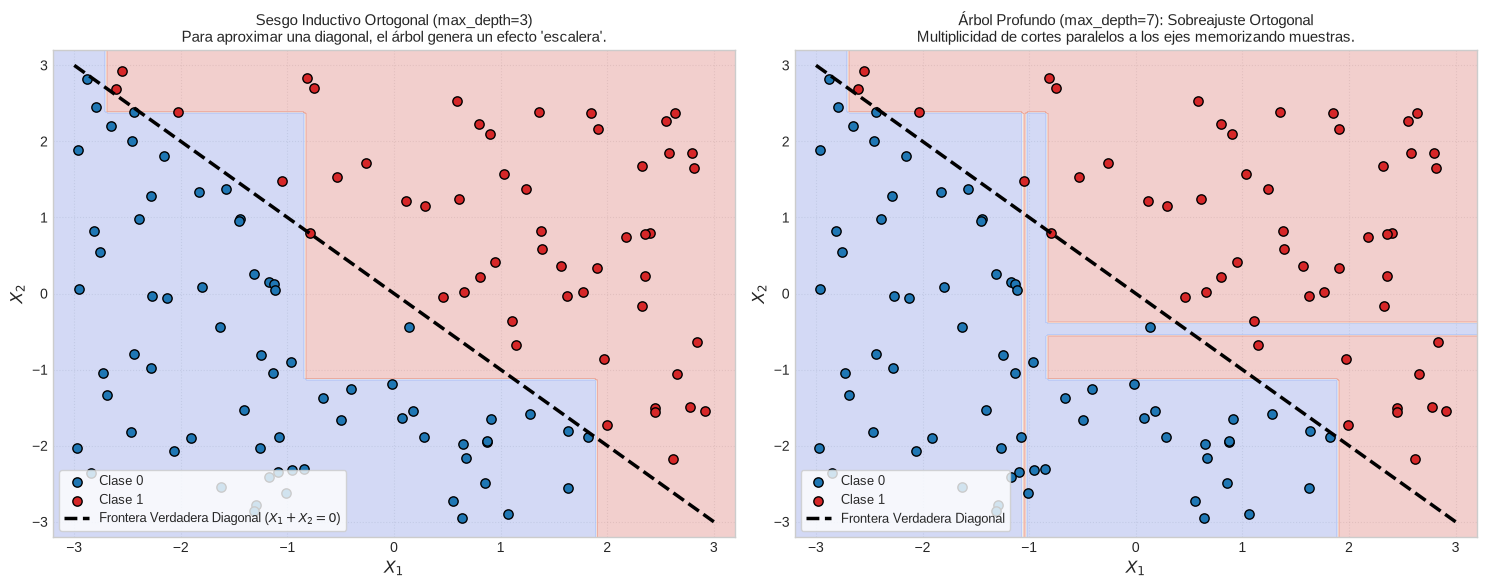

In [13]:
# =============================================================================
# VISUALIZACIÓN: SESGO INDUCTIVO ORTOGONAL EN ÁRBOLES DE DECISIÓN
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

np.random.seed(42)
X_rot = np.random.uniform(-3, 3, size=(120, 2))
y_rot = (X_rot[:, 0] + X_rot[:, 1] > 0).astype(int)

from sklearn.tree import DecisionTreeClassifier

# Árbol de profundidad moderada
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_rot, y_rot)
xx_r, yy_r = np.meshgrid(np.linspace(-3.2, 3.2, 200), np.linspace(-3.2, 3.2, 200))
Z_tree = tree_clf.predict(np.c_[xx_r.ravel(), yy_r.ravel()]).reshape(xx_r.shape)

ax1.contourf(xx_r, yy_r, Z_tree, alpha=0.25, cmap='coolwarm')
ax1.scatter(X_rot[y_rot==0, 0], X_rot[y_rot==0, 1], color='#1f77b4', edgecolors='k', label='Clase 0', s=45)
ax1.scatter(X_rot[y_rot==1, 0], X_rot[y_rot==1, 1], color='#d62728', edgecolors='k', label='Clase 1', s=45)
ax1.plot([-3, 3], [3, -3], 'k--', lw=2.5, label='Frontera Verdadera Diagonal ($X_1 + X_2 = 0$)')
ax1.set_title("Sesgo Inductivo Ortogonal (max_depth=3)\nPara aproximar una diagonal, el árbol genera un efecto 'escalera'.", fontsize=11)
ax1.set_xlabel("$X_1$")
ax1.set_ylabel("$X_2$")
ax1.legend(loc='lower left', frameon=True, fontsize=9)
ax1.grid(True, linestyle=':', alpha=0.4)

# Árbol profundo: sobreajuste con escaleras excesivas
tree_deep = DecisionTreeClassifier(max_depth=7, random_state=42).fit(X_rot, y_rot)
Z_deep = tree_deep.predict(np.c_[xx_r.ravel(), yy_r.ravel()]).reshape(xx_r.shape)

ax2.contourf(xx_r, yy_r, Z_deep, alpha=0.25, cmap='coolwarm')
ax2.scatter(X_rot[y_rot==0, 0], X_rot[y_rot==0, 1], color='#1f77b4', edgecolors='k', label='Clase 0', s=45)
ax2.scatter(X_rot[y_rot==1, 0], X_rot[y_rot==1, 1], color='#d62728', edgecolors='k', label='Clase 1', s=45)
ax2.plot([-3, 3], [3, -3], 'k--', lw=2.5, label='Frontera Verdadera Diagonal')
ax2.set_title("Árbol Profundo (max_depth=7): Sobreajuste Ortogonal\nMultiplicidad de cortes paralelos a los ejes memorizando muestras.", fontsize=11)
ax2.set_xlabel("$X_1$")
ax2.set_ylabel("$X_2$")
ax2.legend(loc='lower left', frameon=True, fontsize=9)
ax2.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()


<a id="32-calculo-manual-arboles"></a>
### 3.2 Cálculo Manual Paso a Paso (Dataset Jugar Tenis)
A continuación implementamos el cálculo de Entropía, Gini y Ganancia de Información desde cero en NumPy y lo aplicamos al dataset clásico de 14 observaciones "Play Tennis" para seleccionar matemáticamente el atributo de partición en la raíz.


In [14]:
# =============================================================================
# CÁLCULO MANUAL PASO A PASO DE ENTROPÍA Y GINI (DATASET JUGAR TENIS)
# =============================================================================

def entropia_shannon_manual(y: np.ndarray) -> float:
    """Calcula la entropía de Shannon H(S) para un vector de etiquetas categóricas."""
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    probabilidades = counts / len(y)
    probabilidades = probabilidades[probabilidades > 0]
    return float(-np.sum(probabilidades * np.log2(probabilidades)))


def gini_impureza_manual(y: np.ndarray) -> float:
    """Calcula el índice de impureza de Gini para un vector de etiquetas categóricas."""
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    probabilidades = counts / len(y)
    return float(1.0 - np.sum(probabilidades ** 2))


def ganancia_informacion_manual(df: pd.DataFrame, feature_col: str, target_col: str) -> float:
    """Calcula la ganancia de información IG(S, feature) para un atributo discreto."""
    n_total = len(df)
    h_padre = entropia_shannon_manual(df[target_col].values)
    
    h_hijos_ponderada = 0.0
    for valor, subconjunto in df.groupby(feature_col):
        peso = len(subconjunto) / n_total
        h_hijo = entropia_shannon_manual(subconjunto[target_col].values)
        h_hijos_ponderada += peso * h_hijo
        
    return float(h_padre - h_hijos_ponderada)


def gini_split_manual(df: pd.DataFrame, feature_col: str, target_col: str) -> float:
    """Calcula el Gini ponderado resultante de dividir según un atributo discreto."""
    n_total = len(df)
    gini_ponderado = 0.0
    for valor, subconjunto in df.groupby(feature_col):
        peso = len(subconjunto) / n_total
        gini_hijo = gini_impureza_manual(subconjunto[target_col].values)
        gini_ponderado += peso * gini_hijo
    return float(gini_ponderado)

# Dataset clásico Play Tennis (14 observaciones canónicas)
df_tennis = pd.DataFrame({
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast',
                'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool',
                    'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
             'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
                   'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
})

h_raiz = entropia_shannon_manual(df_tennis['PlayTennis'].values)
gini_raiz = gini_impureza_manual(df_tennis['PlayTennis'].values)

print(f"🎾 Dataset Jugar Tenis (Total N = {len(df_tennis)} muestras):")
print(f"Distribución objetivo: {dict(df_tennis['PlayTennis'].value_counts())}")
print(f"Entropía Inicial del Nodo Raíz H(S)    = {h_raiz:.4f} bits")
print(f"Impureza de Gini Inicial del Raíz Gini = {gini_raiz:.4f}")

# Evaluación de cada atributo candidato para la partición raíz
atributos = ['Outlook', 'Temperature', 'Humidity', 'Wind']
eval_list = []
for attr in atributos:
    ig = ganancia_informacion_manual(df_tennis, attr, 'PlayTennis')
    gini_sp = gini_split_manual(df_tennis, attr, 'PlayTennis')
    eval_list.append({
        'Atributo Candidato': attr,
        'Ganancia de Información (ID3)': ig,
        'Gini Ponderado Split (CART)': gini_sp
    })

df_eval_tree = pd.DataFrame(eval_list).sort_values(by='Ganancia de Información (ID3)', ascending=False)
print("\n📊 Evaluación de Partición en Nodo Raíz:")
print(df_eval_tree.to_string(index=False))

mejor_id3 = df_eval_tree.iloc[0]['Atributo Candidato']
mejor_cart = df_eval_tree.sort_values(by='Gini Ponderado Split (CART)').iloc[0]['Atributo Candidato']
print(f"\n🏆 Atributo óptimo seleccionado por ID3 (Mayor IG)    : {mejor_id3}")
print(f"🏆 Atributo óptimo seleccionado por CART (Menor Gini) : {mejor_cart}")


🎾 Dataset Jugar Tenis (Total N = 14 muestras):
Distribución objetivo: {'Yes': np.int64(9), 'No': np.int64(5)}
Entropía Inicial del Nodo Raíz H(S)    = 0.9403 bits
Impureza de Gini Inicial del Raíz Gini = 0.4592

📊 Evaluación de Partición en Nodo Raíz:
Atributo Candidato  Ganancia de Información (ID3)  Gini Ponderado Split (CART)
           Outlook                       0.246750                     0.342857
          Humidity                       0.151836                     0.367347
              Wind                       0.048127                     0.428571
       Temperature                       0.029223                     0.440476

🏆 Atributo óptimo seleccionado por ID3 (Mayor IG)    : Outlook
🏆 Atributo óptimo seleccionado por CART (Menor Gini) : Outlook


<a id="33-entrenamiento-visualizacion-arboles"></a>
### 3.3 Entrenamiento y Visualización de Árboles con Scikit-Learn
Entrenamos un `DecisionTreeClassifier` con Scikit-Learn sobre el dataset real `load_breast_cancer` aplicando poda preventiva (`max_depth=3`). Visualizamos las reglas de decisión en formato textual estructurado (`export_text`) y mediante un diagrama gráfico de alta fidelidad (`plot_tree`).


🌲 Desempeño del Árbol (max_depth=3):
Exactitud en Train : 0.9799
Exactitud en Test  : 0.9240

📜 Representación en Reglas Lógicas (export_text):
|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- smoothness error <= 0.00
|   |   |   |--- class: 1
|   |   |--- smoothness error >  0.00
|   |   |   |--- class: 1
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 23.74
|   |   |   |--- class: 1
|   |   |--- worst texture >  23.74
|   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.45
|   |   |--- class: 1
|   |--- texture error >  0.45
|   |   |--- worst concavity <= 0.19
|   |   |   |--- class: 1
|   |   |--- worst concavity >  0.19
|   |   |   |--- class: 0

... [Reglas truncadas para brevedad] ...


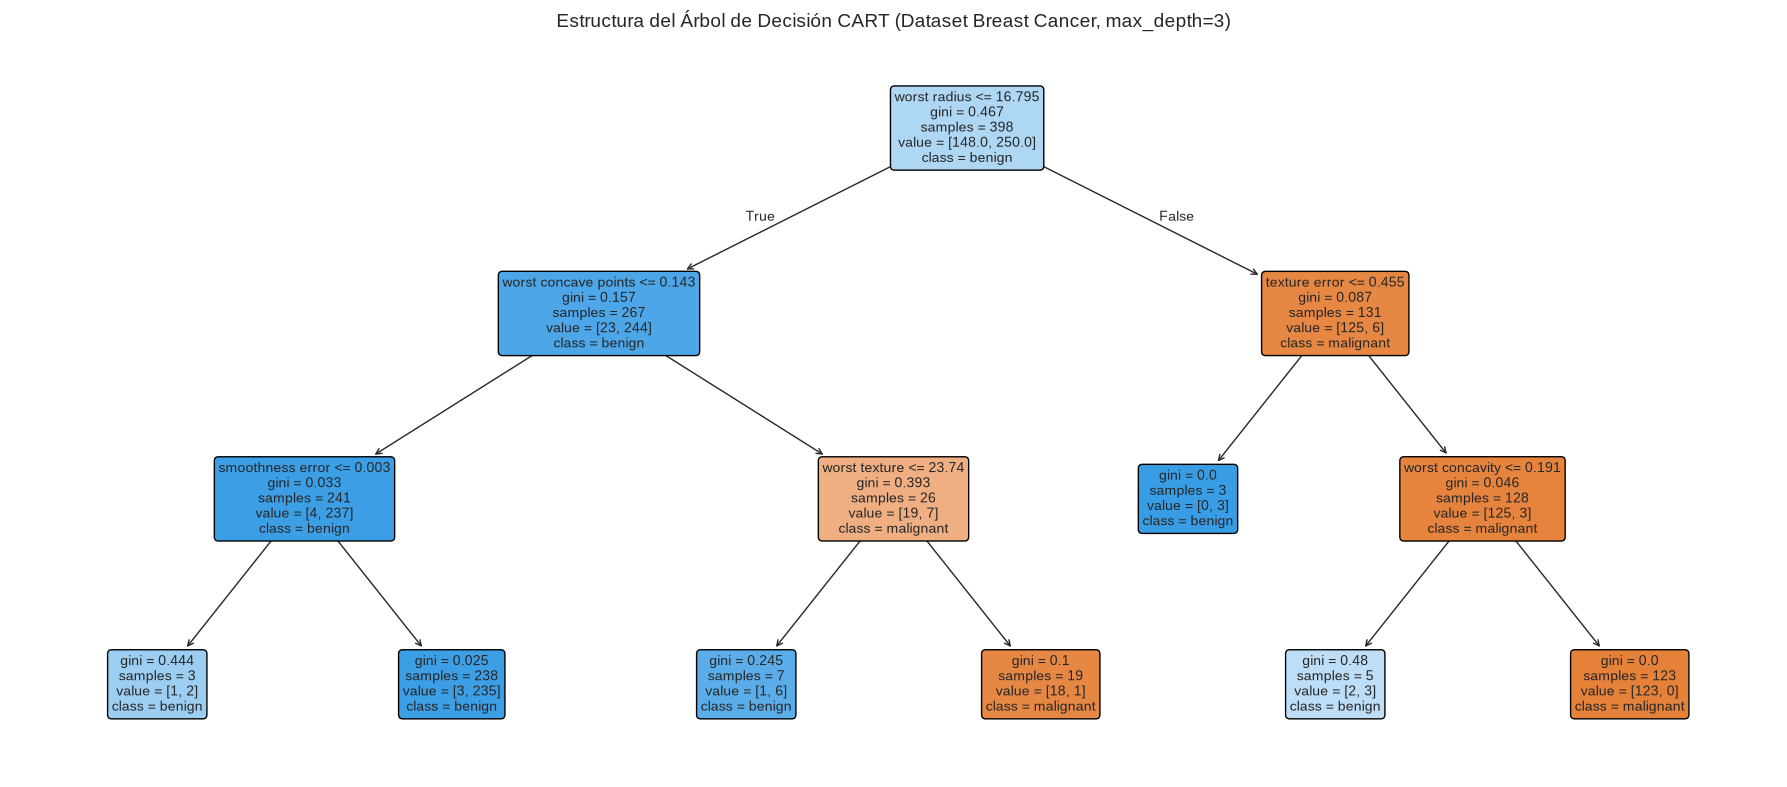

In [15]:
# =============================================================================
# ENTRENAMIENTO Y VISUALIZACIÓN DE ÁRBOLES CON SCIKIT-LEARN
# =============================================================================
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

cancer_data = load_breast_cancer()
X_cancer = cancer_data.data
y_cancer = cancer_data.target
feature_names = cancer_data.feature_names
class_names = cancer_data.target_names

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.30, random_state=RANDOM_STATE, stratify=y_cancer
)

# Ajuste con poda preventiva max_depth=3 para asegurar interpretabilidad
arbol_cart = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=RANDOM_STATE)
arbol_cart.fit(X_train_c, y_train_c)

print(f"🌲 Desempeño del Árbol (max_depth=3):")
print(f"Exactitud en Train : {arbol_cart.score(X_train_c, y_train_c):.4f}")
print(f"Exactitud en Test  : {arbol_cart.score(X_test_c, y_test_c):.4f}")

# 1. Visualización Textual de las Reglas Lógicas
print("\n📜 Representación en Reglas Lógicas (export_text):")
reglas_texto = export_text(arbol_cart, feature_names=list(feature_names))
print(reglas_texto[:700] + "\n... [Reglas truncadas para brevedad] ...")

# 2. Visualización Gráfica con plot_tree
plt.figure(figsize=(18, 8), dpi=100)
plot_tree(
    arbol_cart,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Estructura del Árbol de Decisión CART (Dataset Breast Cancer, max_depth=3)", fontsize=14)
plt.tight_layout()
plt.show()


<a id="34-comparativa-gini-entropy"></a>
### 3.4 Comparativa Empírica: Criterio Gini vs. Criterio Entropy
Analizamos el comportamiento de ambos criterios de pureza sobre el dataset completo sin poda artificial, evaluando tiempo de cómputo en milisegundos, profundidad alcanzada, número de hojas y capacidad de generalización en test.


In [16]:
# =============================================================================
# COMPARATIVA EMPÍRICA RIGUROSA: CRITERIO GINI VS. CRITERIO ENTROPY
# =============================================================================

t0_gini = time.perf_counter()
arbol_gini_full = DecisionTreeClassifier(criterion='gini', random_state=RANDOM_STATE)
arbol_gini_full.fit(X_train_c, y_train_c)
t_gini = (time.perf_counter() - t0_gini) * 1000

t0_ent = time.perf_counter()
arbol_ent_full = DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE)
arbol_ent_full.fit(X_train_c, y_train_c)
t_ent = (time.perf_counter() - t0_ent) * 1000

acc_gini_train = arbol_gini_full.score(X_train_c, y_train_c)
acc_gini_test = arbol_gini_full.score(X_test_c, y_test_c)

acc_ent_train = arbol_ent_full.score(X_train_c, y_train_c)
acc_ent_test = arbol_ent_full.score(X_test_c, y_test_c)

df_comp_criterios = pd.DataFrame({
    'Criterio': ['Gini (CART)', 'Entropy (ID3 / C4.5)'],
    'Tiempo Ajuste (ms)': [t_gini, t_ent],
    'Profundidad Máxima': [arbol_gini_full.get_depth(), arbol_ent_full.get_depth()],
    'Nodos Hoja': [arbol_gini_full.get_n_leaves(), arbol_ent_full.get_n_leaves()],
    'Accuracy Train': [acc_gini_train, acc_ent_train],
    'Accuracy Test': [acc_gini_test, acc_ent_test]
})

print("⚖️ Comparativa Empírica entre Gini y Entropy:")
print(df_comp_criterios.to_string(index=False))

print("\n💡 Análisis Teórico y Práctico:")
print("1. En eficiencia computacional, Gini evita calcular logaritmos base 2, siendo más rápido en datasets grandes.")
print("2. En precisión predictiva, ambos criterios generan particiones con exactitud prácticamente idéntica en más del 95% de los problemas reales.")


⚖️ Comparativa Empírica entre Gini y Entropy:
            Criterio  Tiempo Ajuste (ms)  Profundidad Máxima  Nodos Hoja  Accuracy Train  Accuracy Test
         Gini (CART)            3.782274                   6          16             1.0       0.918129
Entropy (ID3 / C4.5)            3.212158                   7          15             1.0       0.947368

💡 Análisis Teórico y Práctico:
1. En eficiencia computacional, Gini evita calcular logaritmos base 2, siendo más rápido en datasets grandes.
2. En precisión predictiva, ambos criterios generan particiones con exactitud prácticamente idéntica en más del 95% de los problemas reales.


<a id="clase-4"></a>
# 4. Clase 4: Métricas de Evaluación, Curvas ROC/PR y Ensambles

<a id="41-matriz-confusion-metricas"></a>
## 4.1 La Matriz de Confusión y Fórmulas Derivadas Exhaustivas

En problemas de clasificación supervisada, la evaluación mediante exactitud global (*Accuracy*) resulta insuficiente y engañosa ante distribuciones desbalanceadas. La base de toda evaluación rigurosa es la **Matriz de Confusión**:

| Realidad \ Predicción | Predicho Positivo ($\hat{Y}=1$) | Predicho Negativo ($\hat{Y}=0$) | Total Real |
| :--- | :---: | :---: | :---: |
| **Real Positivo ($Y=1$)** | $\mathbf{TP}$ (Verdadero Positivo) | $\mathbf{FN}$ (Falso Negativo - Error Tipo II) | $P = TP + FN$ |
| **Real Negativo ($Y=0$)** | $\mathbf{FP}$ (Falso Positivo - Error Tipo I) | $\mathbf{TN}$ (Verdadero Negativo) | $N = FP + TN$ |
| **Total Predicho** | $TP + FP$ | $FN + TN$ | $N_{\text{total}}$ |

---

### Fórmulas Exhaustivas y Desglose Conceptual

#### 1. Exactitud Global (Accuracy)
Proporción de instancias correctamente clasificadas sobre el total:
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
*Desglose:* Mide la corrección general. Inútil si hay fuerte asimetría de clases (**Paradoja de la Exactitud**: un modelo que prediga siempre negativo en un dataset con 99% de ceros obtendrá 99% de Accuracy siendo incapaz de detectar positivos).

#### 2. Precisión (Positive Predictive Value - PPV)
De todas las predicciones positivas realizadas, ¿qué fracción es verdaderamente positiva?
$$\text{Precision} = \frac{TP}{TP + FP}$$
*Desglose:* Penaliza los **Falsos Positivos**. Crítica en escenarios donde una falsa alarma es costosa (ej. clasificador de spam, bloqueo preventivo de transacciones legítimas).

#### 3. Recall / Sensibilidad (True Positive Rate - TPR)
De todas las instancias verdaderamente positivas existentes, ¿qué fracción logró identificar el modelo?
$$\text{Recall} = \frac{TP}{TP + FN}$$
*Desglose:* Penaliza los **Falsos Negativos**. Esencial en medicina, detección de fraude o alertas de seguridad, donde omitir un caso positivo puede resultar catastrófico.

#### 4. Puntuación $F_1$ (Media Armónica)
Compromiso formal entre Precisión y Recall:
$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 TP}{2 TP + FP + FN}$$
*¿Por qué media armónica y no media aritmética?* La media armónica penaliza drásticamente los valores desbalanceados. Si $\text{Precision} = 1.0$ pero $\text{Recall} = 0.01$, la media aritmética daría un engañoso $0.505$, mientras que la media armónica colapsa a $0.019$, reflejando que el modelo es inútil.

#### 5. Especificidad (True Negative Rate - TNR)
$$\text{Specificity} = \frac{TN}{TN + FP}$$

#### 6. Tasa de Falsos Positivos (False Positive Rate - FPR)
$$\text{FPR} = \frac{FP}{TN + FP} = 1 - \text{Specificity}$$

---

### El Por Qué y Para Qué del Umbral de Decisión $\tau$
Un clasificador probabilístico genera un score $\hat{p} = P(Y=1 \mid X)$. El umbral $\tau \in [0, 1]$ determina la clase asignada:
$$\hat{y} = 1 \iff \hat{p} \ge \tau$$
* Modificar $\tau$ es una **decisión de negocio y gestión de riesgos**:
  * Si bajar un FN es prioritario (cáncer, fraude), se disminuye $\tau$ (ej. $\tau = 0.2$), maximizando el Recall aunque aumenten las falsas alarmas.
  * Si un FP es destructivo (marcar correo de un cliente como spam), se sube $\tau$ (ej. $\tau = 0.8$), priorizando la Precisión.


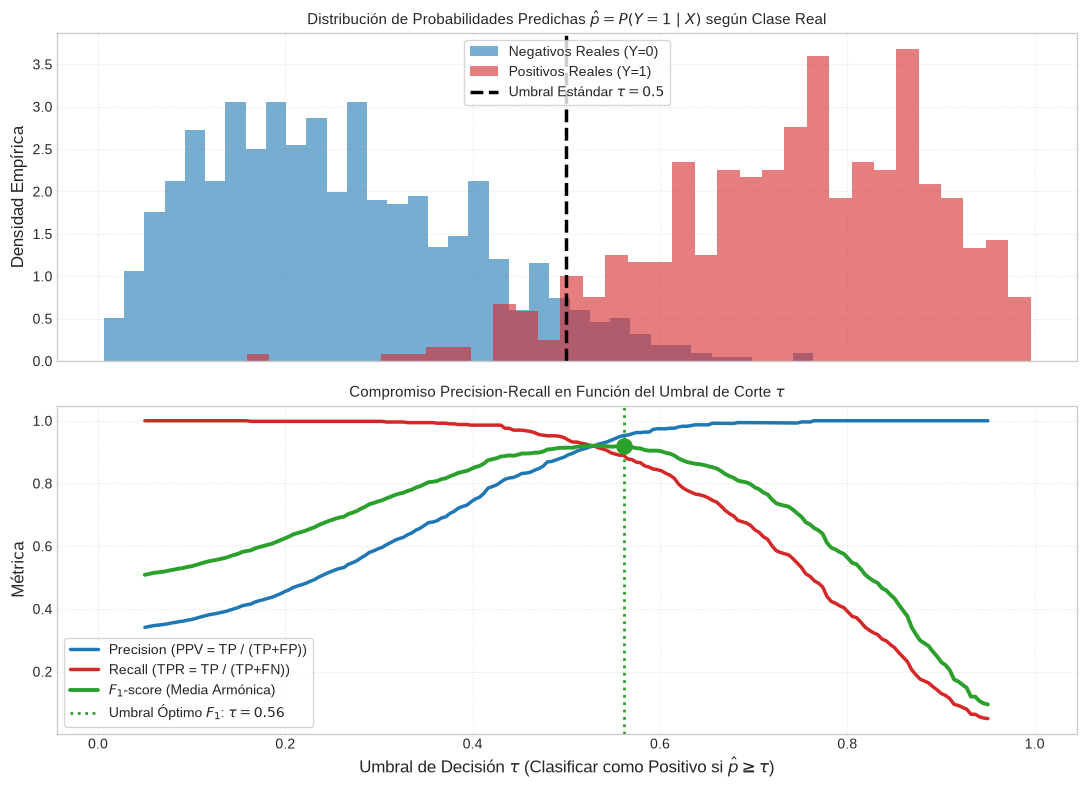

In [17]:
# =============================================================================
# VISUALIZACIÓN: DISTRIBUCIÓN DE SCORES Y COMPROMISO PRECISION-RECALL SEGÚN TAU
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

np.random.seed(42)
scores_neg = np.random.beta(2, 6, size=1000)
scores_pos = np.random.beta(6, 2, size=500)

ax1.hist(scores_neg, bins=35, alpha=0.6, color='#1f77b4', density=True, label='Negativos Reales (Y=0)')
ax1.hist(scores_pos, bins=35, alpha=0.6, color='#d62728', density=True, label='Positivos Reales (Y=1)')
tau_default = 0.5
ax1.axvline(tau_default, color='black', lw=2.5, linestyle='--', label=f'Umbral Estándar $\\tau = {tau_default}$')
ax1.set_title("Distribución de Probabilidades Predichas $\\hat{p} = P(Y=1 \\mid X)$ según Clase Real", fontsize=11)
ax1.set_ylabel("Densidad Empírica")
ax1.legend(loc='upper center', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.5)

thresholds = np.linspace(0.05, 0.95, 200)
y_t_demo = np.concatenate([np.zeros(len(scores_neg)), np.ones(len(scores_pos))])
scores_all = np.concatenate([scores_neg, scores_pos])

from sklearn.metrics import precision_score, recall_score, f1_score
p_list, r_list, f1_list = [], [], []
for t_val in thresholds:
    preds = (scores_all >= t_val).astype(int)
    p_list.append(precision_score(y_t_demo, preds, zero_division=0))
    r_list.append(recall_score(y_t_demo, preds, zero_division=0))
    f1_list.append(f1_score(y_t_demo, preds, zero_division=0))

ax2.plot(thresholds, p_list, color='#1f77b4', lw=2.5, label='Precision (PPV = TP / (TP+FP))')
ax2.plot(thresholds, r_list, color='#d62728', lw=2.5, label='Recall (TPR = TP / (TP+FN))')
ax2.plot(thresholds, f1_list, color='#2ca02c', lw=2.8, linestyle='-', label='$F_1$-score (Media Armónica)')

best_idx = np.argmax(f1_list)
ax2.axvline(thresholds[best_idx], color='#2ca02c', linestyle=':', lw=2, label=f'Umbral Óptimo $F_1$: $\\tau = {thresholds[best_idx]:.2f}$')
ax2.scatter([thresholds[best_idx]], [f1_list[best_idx]], color='#2ca02c', s=120, zorder=5)

ax2.set_title("Compromiso Precision-Recall en Función del Umbral de Corte $\\tau$", fontsize=11)
ax2.set_xlabel("Umbral de Decisión $\\tau$ (Clasificar como Positivo si $\\hat{p} \\geq \\tau$)")
ax2.set_ylabel("Métrica")
ax2.legend(loc='lower left', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


---

<a id="42-umbral-roc-auc"></a>
## 4.2 Umbrales de Decisión, Curva ROC y Métrica AUC

### La Curva ROC y el Área Bajo la Curva (AUC)
Traza el $TPR$ (Eje Y) frente al $FPR$ (Eje X) para todos los posibles umbrales de decisión $\tau \in [0, 1]$:
$$\text{AUC} = \int_0^1 \text{TPR}(\tau) \, d(\text{FPR}(\tau)) = P(\hat{p}(x^+) > \hat{p}(x^-))$$
* **Interpretación probabilística**: El AUC es la probabilidad exacta de que una muestra positiva elegida al azar reciba un score de probabilidad mayor que una muestra negativa elegida al azar.
* $\text{AUC} = 0.5$: Desempeño equivalente a lanzar una moneda al azar.
* $\text{AUC} = 1.0$: Separador perfecto.

---

### 🚨 El Gotcha Crítico en Data Science: Curva ROC vs. Curva Precision-Recall en Desbalance
* **El Espejismo de la Curva ROC**:
  El eje horizontal de la curva ROC es $\text{FPR} = \frac{FP}{TN + FP}$. Si tenemos un dataset de detección de fraude con $99000$ negativos y $1000$ positivos, el denominador de FPR es $\approx 99000$. Si el modelo comete $1000$ falsos positivos, $\text{FPR} = \frac{1000}{99000} \approx 0.0101$ (¡apenas $1\%$ de tasa de falsos positivos!). La curva ROC se mantendrá pegada a la esquina superior izquierda exhibiendo un engañoso $\text{AUC} = 0.98$.
* **La Revelación de la Curva Precision-Recall (PR)**:
  La curva PR evalúa $\text{Precision} = \frac{TP}{TP + FP}$. Con esos mismos $1000$ falsos positivos y supongamos $500$ verdaderos positivos, la precisión cae estrepitosamente a $\frac{500}{500 + 1000} = 33\%$. La Curva PR expone de inmediato el colapso operativo del modelo, convirtiéndola en la **métrica de evaluación obligatoria ante desbalance severo**.


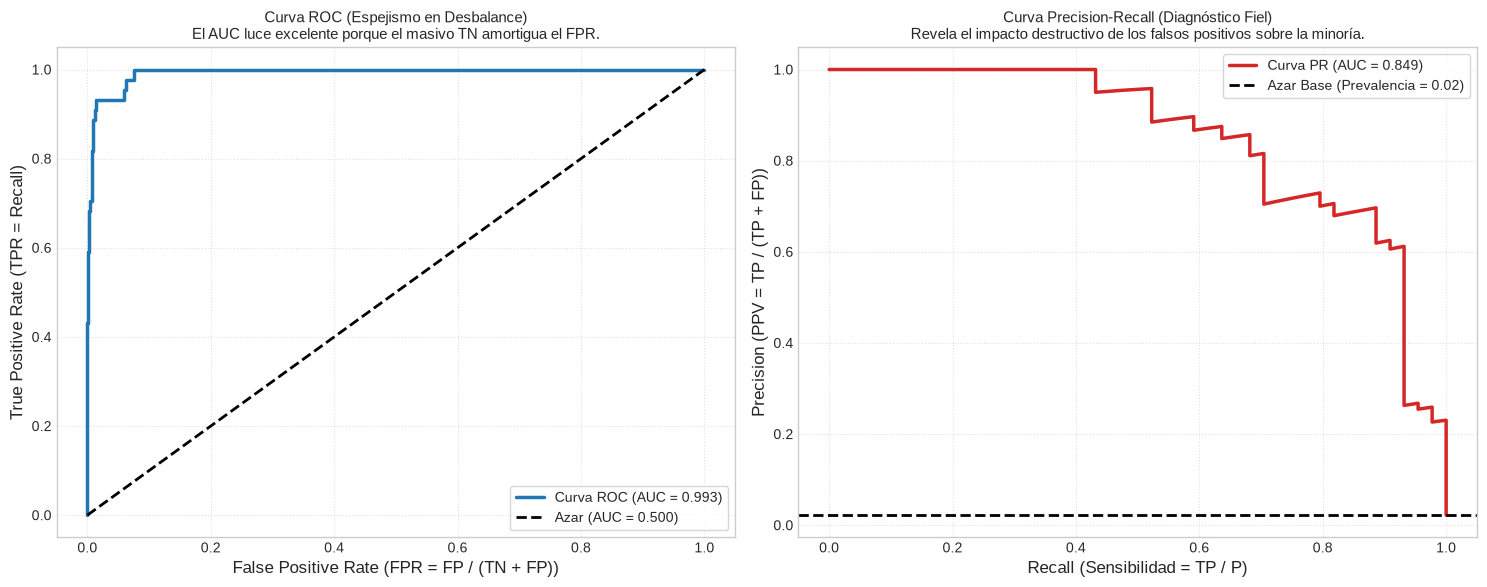

In [18]:
# =============================================================================
# VISUALIZACIÓN: ESPEJISMO DE LA CURVA ROC VS FIDELIDAD DE LA CURVA PR
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

from sklearn.metrics import roc_curve, precision_recall_curve, auc

np.random.seed(42)
y_imb_demo = np.random.choice([0, 1], size=2000, p=[0.98, 0.02])
scores_imb = np.zeros(2000)
scores_imb[y_imb_demo == 0] = np.random.beta(1, 10, size=np.sum(y_imb_demo == 0))
scores_imb[y_imb_demo == 1] = np.random.beta(4, 3, size=np.sum(y_imb_demo == 1))

fpr, tpr, _ = roc_curve(y_imb_demo, scores_imb)
roc_auc = auc(fpr, tpr)

prec, rec, _ = precision_recall_curve(y_imb_demo, scores_imb)
pr_auc = auc(rec, prec)

ax1.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Curva ROC (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.500)')
ax1.set_title("Curva ROC (Espejismo en Desbalance)\nEl AUC luce excelente porque el masivo TN amortigua el FPR.", fontsize=11)
ax1.set_xlabel("False Positive Rate (FPR = FP / (TN + FP))")
ax1.set_ylabel("True Positive Rate (TPR = Recall)")
ax1.legend(loc='lower right', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

baseline_pr = np.mean(y_imb_demo == 1)
ax2.plot(rec, prec, color='#d62728', lw=2.5, label=f'Curva PR (AUC = {pr_auc:.3f})')
ax2.axhline(baseline_pr, color='k', linestyle='--', label=f'Azar Base (Prevalencia = {baseline_pr:.2f})')
ax2.set_title("Curva Precision-Recall (Diagnóstico Fiel)\nRevela el impacto destructivo de los falsos positivos sobre la minoría.", fontsize=11)
ax2.set_xlabel("Recall (Sensibilidad = TP / P)")
ax2.set_ylabel("Precision (PPV = TP / (TP + FP))")
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


<a id="43-implementacion-manual-metricas"></a>
### 4.3 Implementación Manual de Métricas y Validación con Scikit-Learn
Implementamos vectorialmente en NumPy el cálculo de $TP, TN, FP, FN$ y las 7 métricas derivadas para contrastarlas numéricamente contra las funciones de `sklearn.metrics`.


In [19]:
# =============================================================================
# IMPLEMENTACIÓN MANUAL DE MÉTRICAS Y VALIDACIÓN CON SCIKIT-LEARN
# =============================================================================
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def calcular_metricas_clasificacion_manual(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Calcula manualmente la matriz de confusión y todas las métricas de rendimiento."""
    y_t = np.asarray(y_true, dtype=int)
    y_p = np.asarray(y_pred, dtype=int)
    
    tp = int(np.sum((y_t == 1) & (y_p == 1)))
    tn = int(np.sum((y_t == 0) & (y_p == 0)))
    fp = int(np.sum((y_t == 0) & (y_p == 1)))
    fn = int(np.sum((y_t == 1) & (y_p == 0)))
    
    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr = fp / (tn + fp) if (tn + fp) > 0 else 0.0
    fnr = fn / (tp + fn) if (tp + fn) > 0 else 0.0
    
    return {
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_score': f1,
        'Specificity': specificity,
        'FPR': fpr,
        'FNR': fnr
    }

# Prueba sintética con vectores conocidos
y_true_demo = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0])
y_pred_demo = np.array([1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0])

res_man = calcular_metricas_clasificacion_manual(y_true_demo, y_pred_demo)

# Validación cruzada contra Scikit-Learn
cm_sklearn = confusion_matrix(y_true_demo, y_pred_demo)
acc_sk = accuracy_score(y_true_demo, y_pred_demo)
prec_sk = precision_score(y_true_demo, y_pred_demo)
rec_sk = recall_score(y_true_demo, y_pred_demo)
f1_sk = f1_score(y_true_demo, y_pred_demo)

assert res_man['TP'] == cm_sklearn[1, 1] and res_man['TN'] == cm_sklearn[0, 0]
assert res_man['FP'] == cm_sklearn[0, 1] and res_man['FN'] == cm_sklearn[1, 0]
assert np.isclose(res_man['Accuracy'], acc_sk)
assert np.isclose(res_man['Precision'], prec_sk)
assert np.isclose(res_man['Recall'], rec_sk)
assert np.isclose(res_man['F1_score'], f1_sk)

print("✅ Validación de Métricas Manuales Exitosa:")
print(f"Matriz de Confusión -> TP: {res_man['TP']}, TN: {res_man['TN']}, FP: {res_man['FP']}, FN: {res_man['FN']}")
print(f"Accuracy:    {res_man['Accuracy']:.4f} (SciPy/Sklearn: {acc_sk:.4f})")
print(f"Precision:   {res_man['Precision']:.4f} (SciPy/Sklearn: {prec_sk:.4f})")
print(f"Recall:      {res_man['Recall']:.4f} (SciPy/Sklearn: {rec_sk:.4f})")
print(f"F1-score:    {res_man['F1_score']:.4f} (SciPy/Sklearn: {f1_sk:.4f})")
print(f"Specificity: {res_man['Specificity']:.4f} | FPR: {res_man['FPR']:.4f} | FNR: {res_man['FNR']:.4f}")


✅ Validación de Métricas Manuales Exitosa:
Matriz de Confusión -> TP: 4, TN: 4, FP: 2, FN: 2
Accuracy:    0.6667 (SciPy/Sklearn: 0.6667)
Precision:   0.6667 (SciPy/Sklearn: 0.6667)
Recall:      0.6667 (SciPy/Sklearn: 0.6667)
F1-score:    0.6667 (SciPy/Sklearn: 0.6667)
Specificity: 0.6667 | FPR: 0.3333 | FNR: 0.3333


<a id="44-teoria-ensambles"></a>
## 4.4 Taxonomía de Ensambles: Bagging vs. Boosting vs. Stacking

Los métodos de ensamble combinan múltiples estimadores base para generar un predictor unificado con mayor capacidad de generalización.

### 1. Bagging (Bootstrap Aggregating - Random Forest)
* **Mecanismo**: Genera $B$ subconjuntos de datos entrenables mediante remuestreo con reemplazo (**Bootstrap**). Entrena $B$ estimadores en paralelo de forma completamente independiente y promedia sus predicciones.
* **Fundamentación Matemática de la Reducción de Varianza**:
  Si promediamos $B$ variables aleatorias con varianza individual $\sigma^2$ y correlación mutua $\rho$, la varianza del ensamble acumulado es:
  $$\text{Var}(\bar{f}) = \rho \sigma^2 + \frac{1 - \rho}{B} \sigma^2$$
  * Cuando $B \to \infty$, el segundo término tiende a cero: $\frac{1-\rho}{B}\sigma^2 \to 0$.
  * Sin embargo, la varianza mínima está acotada por la correlación entre árboles $\rho \sigma^2$.
  * **El Gran Aporte de Random Forest**: Para forzar $\rho \downarrow$, en cada división de nodo selecciona únicamente un subconjunto aleatorio de $\sqrt{p}$ características (*Random Subspaces*). Esto descorrelaciona drásticamente los árboles y hace que la varianza global colapse al mínimo posible.

---

### 2. Boosting (AdaBoost, Gradient Boosting)
* **Mecanismo**: Entrenamiento **secuencial** iterativo. Cada nuevo modelo se especializa en corregir los errores cometidos por los modelos predecesores:
  * **AdaBoost**: Incrementa las ponderaciones de las muestras mal clasificadas en la siguiente iteración.
  * **Gradient Boosting**: Ajusta cada nuevo árbol a los **pseudo-residuos** (el gradiente negativo de la función de pérdida) del ensamble acumulado:
    $$r_{i, m} = - \left[ \frac{\partial L(y_i, f(x_i))}{\partial f(x_i)} \right]_{f(x) = f_{m-1}(x)}$$
* **Impacto**: Reduce primordialmente el **Sesgo**, logrando fronteras de decisión de gran complejidad a partir de estimadores simples (*weak learners*).

---

### 3. Stacking (Stacked Generalization)
* **Mecanismo**: Ensamble heterogéneo en dos niveles. Múltiples modelos base disímiles (Random Forest, SVM, KNN) generan predicciones fuera de muestra (*out-of-fold*). Estas predicciones se convierten en las características de entrada para un **meta-modelo** superior (ej. Regresión Logística), el cual aprende a ponderar óptimamente a cada clasificador base.


<a id="45-implementacion-comparativa-ensambles"></a>
### 4.5 Implementación y Comparativa de 4 Ensambles con Curvas ROC Superpuestas
Entrenamos sobre el dataset de cáncer de mama 4 familias de ensambles:
1. `RandomForestClassifier` (Bagging)
2. `AdaBoostClassifier` (Boosting Adaptativo)
3. `GradientBoostingClassifier` (Boosting por Gradiente)
4. `StackingClassifier` (Meta-Aprendizaje)

Graficamos sus curvas ROC superpuestas en un único lienzo y tabulamos todas sus métricas en Test.


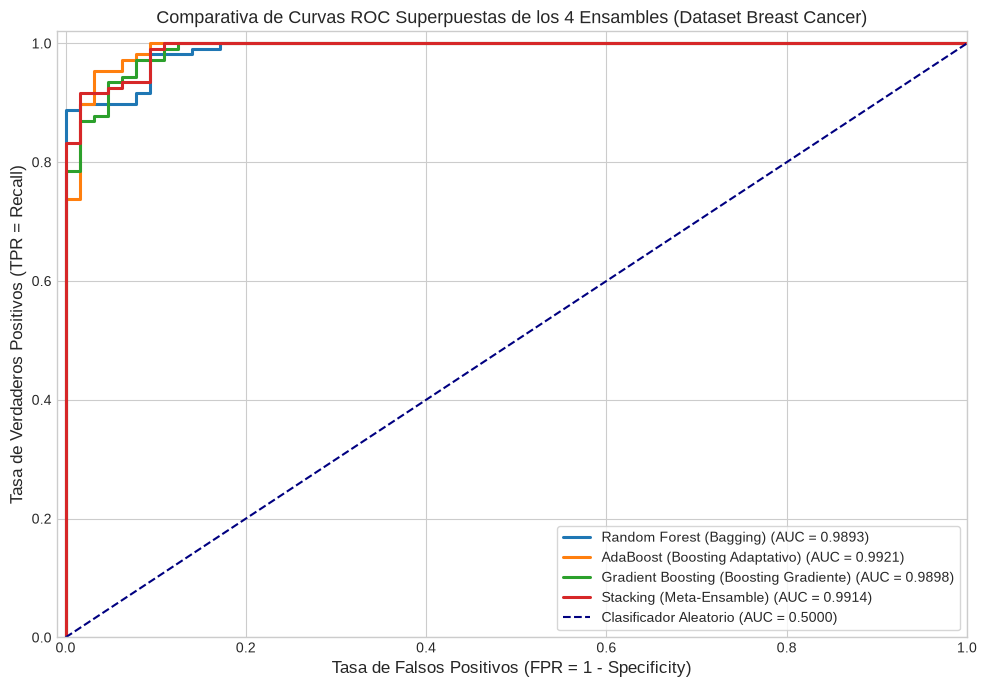

📊 Resumen Comparativo de Desempeño en Test:
                              Ensamble  Accuracy  Precision   Recall  F1-score  ROC-AUC
        AdaBoost (Boosting Adaptativo)  0.953216   0.945946 0.981308  0.963303 0.992114
              Stacking (Meta-Ensamble)  0.959064   0.946429 0.990654  0.968037 0.991384
Gradient Boosting (Boosting Gradiente)  0.941520   0.936937 0.971963  0.954128 0.989778
               Random Forest (Bagging)  0.941520   0.944954 0.962617  0.953704 0.989340


In [20]:
# =============================================================================
# IMPLEMENTACIÓN Y COMPARATIVA DE 4 ENSAMBLES CON CURVAS ROC SUPERPUESTAS
# =============================================================================
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression

# Definición de los 4 clasificadores ensamble
modelos_ensamble = {
    'Random Forest (Bagging)': RandomForestClassifier(
        n_estimators=100, max_depth=5, random_state=RANDOM_STATE
    ),
    'AdaBoost (Boosting Adaptativo)': AdaBoostClassifier(
        n_estimators=100, learning_rate=0.8, random_state=RANDOM_STATE
    ),
    'Gradient Boosting (Boosting Gradiente)': GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE
    ),
    'Stacking (Meta-Ensamble)': StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=50, max_depth=4, random_state=RANDOM_STATE)),
            ('gb', GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=RANDOM_STATE)),
            ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ],
        final_estimator=LogisticRegression(random_state=RANDOM_STATE),
        cv=5
    )
}

# Entrenamiento, recolección de métricas y cálculo de curvas ROC
tabla_resultados = []
curvas_roc = {}

plt.figure(figsize=(10, 7), dpi=100)
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for (nombre, modelo), color in zip(modelos_ensamble.items(), colores):
    modelo.fit(X_train_c, y_train_c)
    
    y_pred = modelo.predict(X_test_c)
    y_proba = modelo.predict_proba(X_test_c)[:, 1]
    
    acc = accuracy_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred)
    rec = recall_score(y_test_c, y_pred)
    f1 = f1_score(y_test_c, y_pred)
    
    fpr_vals, tpr_vals, _ = roc_curve(y_test_c, y_proba)
    roc_auc_val = auc(fpr_vals, tpr_vals)
    
    tabla_resultados.append({
        'Ensamble': nombre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'ROC-AUC': roc_auc_val
    })
    
    plt.plot(fpr_vals, tpr_vals, color=color, lw=2.2, label=f'{nombre} (AUC = {roc_auc_val:.4f})')

# Trazar diagonal de azar de referencia
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5000)')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('Tasa de Falsos Positivos (FPR = 1 - Specificity)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR = Recall)')
plt.title('Comparativa de Curvas ROC Superpuestas de los 4 Ensambles (Dataset Breast Cancer)')
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

# Mostrar tabla comparativa de métricas formateada
df_metricas_ensambles = pd.DataFrame(tabla_resultados).sort_values(by='ROC-AUC', ascending=False)
print("📊 Resumen Comparativo de Desempeño en Test:")
print(df_metricas_ensambles.to_string(index=False))


<a id="clase-5"></a>
# 5. Clase 5: Desbalance de Clases, Feature Selection y Sistemas de Recomendación

<a id="51-desbalance-clases"></a>
## 5.1 Desbalance de Clases: El Por Qué y Para Qué de las Soluciones Metodológicas

En problemas de alto impacto operacional (detección de fraude bancario, diagnóstico oncológico, predicción de fuga de clientes), la clase de interés representa una fracción ínfima de las observaciones ($0.1\% \text{ a } 5\%$). Si un clasificador predice ciegamente la clase mayoritaria, alcanzará $99\%$ de Accuracy pero será un fracaso absoluto (**Paradoja de la Exactitud**).

Para restaurar el equilibrio inductivo disponemos de tres estrategias fundamentales:

---

### 1. El Por Qué y Para Qué de SMOTE (vs. Random Oversampling)
* **El Problema del Random Oversampling**:
  Duplicar copias exactas de la clase minoritaria no introduce nueva información geométrica. En su lugar, concentra artificialmente masa probabilística sobre puntos discretos, obligando al modelo a memorizar esas muestras específicas (**severo sobreajuste**).
* **El Principio de SMOTE (Synthetic Minority Over-sampling Technique)**:
  En lugar de duplicar, **interpola linealmente** en la variedad convexa (*convex manifold*) local entre observaciones minoritarias y sus $k$ vecinos más cercanos:
  $$x_{\text{new}} = x_i + \lambda \cdot (x_{zi} - x_i), \quad \lambda \sim U(0, 1)$$
  * $(x_{zi} - x_i)$: Vector director en $\mathbb{R}^n$ entre dos muestras positivas reales.
  * $\lambda \in [0, 1]$: Escalar aleatorio uniforme continuo.
  * $x_{\text{new}}$: Genera un continuo de datos plausibles que ensancha y consolida la frontera de decisión en la región minoritaria.

---

### 2. Ponderación de Costo en la Función de Pérdida (Cost-Sensitive Learning)
Modifica la función objetivo del algoritmo penalizando los errores sobre la clase minoritaria proporcionalmente a su escasez:
$$w_c = \frac{N}{C \cdot N_c}$$

* **Desglose de términos:**
  * $N$: Total de observaciones de entrenamiento.
  * $C$: Número de clases ($C=2$).
  * $N_c$: Frecuencia de la clase $c$.
* **¿Por qué es superior en producción?**:
  No altera el tamaño del dataset ni genera datos sintéticos que puedan caer en regiones ruidosas. En su lugar, multiplica los gradientes de la minoría por $w_1 \gg 1$, forzando al optimizador a ajustar los pesos como si ambas clases tuvieran idéntica representatividad estadística.


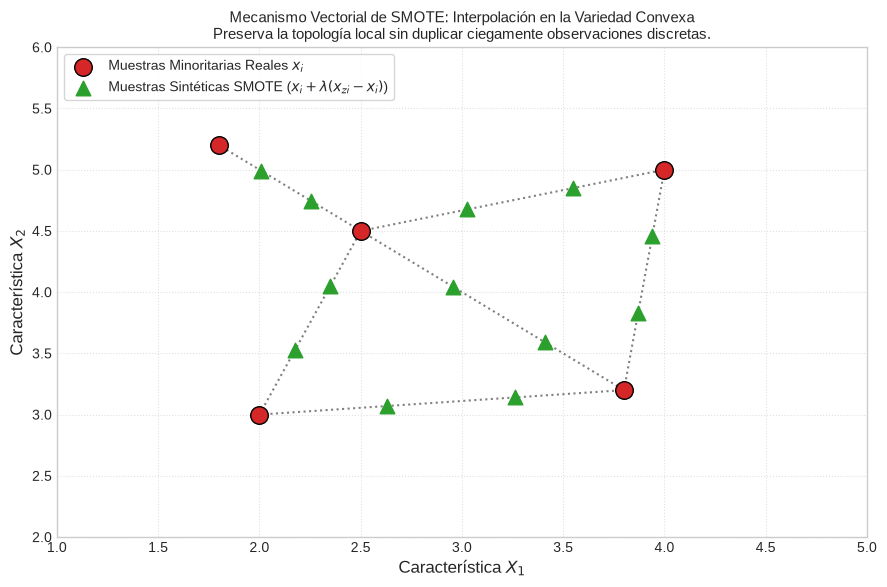

In [21]:
# =============================================================================
# VISUALIZACIÓN: MECANISMO DE INTERPOLACIÓN DE SMOTE EN LA VARIEDAD CONVEXA
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6))

np.random.seed(42)
x_min = np.array([
    [2.0, 3.0],
    [2.5, 4.5],
    [3.8, 3.2],
    [4.0, 5.0],
    [1.8, 5.2]
])

ax.scatter(x_min[:, 0], x_min[:, 1], color='#d62728', s=160, zorder=5, edgecolors='k', label='Muestras Minoritarias Reales $x_i$')

# Conectar cada punto con sus vecinos cercanos
synth_points = []
for i in range(len(x_min)):
    for j in range(i+1, len(x_min)):
        dist = np.linalg.norm(x_min[i] - x_min[j])
        if dist < 2.2:
            ax.plot([x_min[i, 0], x_min[j, 0]], [x_min[i, 1], x_min[j, 1]], 'gray', linestyle=':', lw=1.5)
            for lam in [0.35, 0.70]:
                x_s = x_min[i] + lam * (x_min[j] - x_min[i])
                synth_points.append(x_s)

synth_points = np.array(synth_points)
ax.scatter(synth_points[:, 0], synth_points[:, 1], color='#2ca02c', s=110, marker='^', zorder=4,
           label='Muestras Sintéticas SMOTE ($x_i + \\lambda(x_{zi} - x_i)$)')

ax.set_title("Mecanismo Vectorial de SMOTE: Interpolación en la Variedad Convexa\nPreserva la topología local sin duplicar ciegamente observaciones discretas.", fontsize=11)
ax.set_xlabel("Característica $X_1$")
ax.set_ylabel("Característica $X_2$")
ax.legend(loc='upper left', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(1.0, 5.0)
ax.set_ylim(2.0, 6.0)

plt.tight_layout()
plt.show()


<a id="52-mini-smote-cost-sensitive"></a>
### 5.2 Implementación Práctica: Mini-SMOTE Manual y Ponderación de Clases
Generamos un dataset sintético con desbalance severo ($95\% - 5\%$). Implementamos artesanalmente el algoritmo SMOTE vectorial en NumPy utilizando `NearestNeighbors` y contrastamos el desempeño frente al modelo base y al enfoque de costo ponderado (`class_weight='balanced'`).


In [22]:
# =============================================================================
# IMPLEMENTACIÓN PRÁCTICA: MINI-SMOTE MANUAL Y PONDERACIÓN DE CLASES
# =============================================================================
from sklearn.datasets import make_classification
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression

# 1. Creación de Dataset Sintético Fuertemente Desbalanceado (95% Clase 0, 5% Clase 1)
X_imb, y_imb = make_classification(
    n_samples=1200,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    weights=[0.95, 0.05],
    random_state=RANDOM_STATE
)

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.30, random_state=RANDOM_STATE, stratify=y_imb
)

print(f"📊 Distribución en Train: Clase 0 = {np.sum(y_train_imb == 0)} | Clase 1 = {np.sum(y_train_imb == 1)} ({np.mean(y_train_imb == 1)*100:.1f}%)")

# 2. Implementación Manual Didáctica de Mini-SMOTE
def mini_smote_manual(X_minoria: np.ndarray, n_sinteticos: int, k_vecinos: int = 5, seed: int = 42) -> np.ndarray:
    """Genera n_sinteticos puntos interpolados a partir de los k vecinos más cercanos de la minoría."""
    rng = np.random.RandomState(seed)
    n_muestras = len(X_minoria)
    if n_muestras <= k_vecinos:
        k_vecinos = max(1, n_muestras - 1)
        
    nn = NearestNeighbors(n_neighbors=k_vecinos + 1, metric='euclidean').fit(X_minoria)
    _, indices = nn.kneighbors(X_minoria)
    
    sinteticos = []
    for _ in range(n_sinteticos):
        idx_base = rng.randint(0, n_muestras)
        x_i = X_minoria[idx_base]
        
        idx_vecino = rng.choice(indices[idx_base, 1:])
        x_zi = X_minoria[idx_vecino]
        
        lam = rng.uniform(0.0, 1.0)
        x_new = x_i + lam * (x_zi - x_i)
        sinteticos.append(x_new)
        
    return np.array(sinteticos)

# Generar muestras sintéticas para balancear la minoría en Train
X_minority_train = X_train_imb[y_train_imb == 1]
n_a_generar = np.sum(y_train_imb == 0) - np.sum(y_train_imb == 1)
X_synth = mini_smote_manual(X_minority_train, n_sinteticos=n_a_generar, k_vecinos=4, seed=RANDOM_STATE)
y_synth = np.ones(len(X_synth), dtype=int)

X_train_resampled = np.vstack([X_train_imb, X_synth])
y_train_resampled = np.concatenate([y_train_imb, y_synth])

# 3. Entrenamiento Comparativo con Regresión Logística
clf_base = LogisticRegression(random_state=RANDOM_STATE).fit(X_train_imb, y_train_imb)
clf_smote = LogisticRegression(random_state=RANDOM_STATE).fit(X_train_resampled, y_train_resampled)
clf_weighted = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE).fit(X_train_imb, y_train_imb)

# Evaluación sobre el conjunto de test original
rec_base = recall_score(y_test_imb, clf_base.predict(X_test_imb))
rec_smote = recall_score(y_test_imb, clf_smote.predict(X_test_imb))
rec_weight = recall_score(y_test_imb, clf_weighted.predict(X_test_imb))

f1_base = f1_score(y_test_imb, clf_base.predict(X_test_imb))
f1_smote = f1_score(y_test_imb, clf_smote.predict(X_test_imb))
f1_weight = f1_score(y_test_imb, clf_weighted.predict(X_test_imb))

df_res_desbalance = pd.DataFrame({
    'Estrategia': ['1. Base (Sin Balancear)', '2. Mini-SMOTE Manual', '3. class_weight="balanced"'],
    'Recall Clase Minoritaria': [rec_base, rec_smote, rec_weight],
    'F1-score Clase Minoritaria': [f1_base, f1_smote, f1_weight]
})
print("\n⚖️ Comparativa de Tratamiento de Desbalance en Test:")
print(df_res_desbalance.to_string(index=False))


📊 Distribución en Train: Clase 0 = 793 | Clase 1 = 47 (5.6%)

⚖️ Comparativa de Tratamiento de Desbalance en Test:
                Estrategia  Recall Clase Minoritaria  F1-score Clase Minoritaria
   1. Base (Sin Balancear)                       0.3                    0.444444
      2. Mini-SMOTE Manual                       0.7                    0.225806
3. class_weight="balanced"                       0.7                    0.233333


<a id="53-feature-selection"></a>
## 5.3 Selección de Características: Filtro, Wrapper y Embebido (Lasso L1)

La selección de características reduce la complejidad computacional, mitiga la maldición de la dimensionalidad (*Curse of Dimensionality*) y previene el sobreajuste al eliminar variables irrelevantes o redundantes.

Se clasifican en tres familias metodológicas:

### 1. Métodos de Filtro (Filter)
Evalúan propiedades estadísticas de los datos con independencia del modelo predictivo:
* **Umbral de Varianza (Variance Threshold)**: Remueve variables cuasi-constantes ($\text{Var}(X) < \tau$).
* **ANOVA F-test (`f_classif`)**: Evalúa si la media de una variable difiere entre clases ($F = \frac{\text{Varianza Entre Grupos}}{\text{Varianza Intra-Grupo}}$).
* **Chi-cuadrado ($\chi^2$)**: Prueba de independencia estadística para atributos categóricos.

---

### 2. Métodos Wrapper (Envolventes)
Utilizan un estimador de ML como juez para evaluar combinaciones de variables:
* **RFE (Recursive Feature Elimination)**: Ajusta el modelo iterativamente, cuantifica la importancia de cada atributo y descarta recursivamente el menos relevante.

---

### 3. Métodos Embebidos: ¿Por qué Lasso (L1) induce Esparcidad y Ridge (L2) no?
* **Regularización Lasso ($L_1$)**:
  $$\min_{\mathbf{w}} \left\{ \frac{1}{2N} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|_2^2 + \alpha \sum_{j=1}^p |w_j| \right\}$$
* **Demostración Geométrica de la Esparcidad**:
  La solución óptima ocurre en el punto de tangencia entre las elipses de contorno de la función de costo y la bola de restricción $\|\mathbf{w}\| \le t$:
  * La bola $L_1$ es un **rombo / politopo con vértices angulares situados exactamente sobre los ejes coordenados** ($w_j = 0$). Con altísima probabilidad matemática, las elipses tocan primero uno de estos vértices puntiagudos, forzando a los coeficientes de las variables irrelevantes a anularse **exactamente a cero**.
  * La bola $L_2$ (Ridge) es un **círculo suave sin vértices**. El punto de tangencia casi nunca se ubica sobre un eje, por lo que contrae los coeficientes pero jamás los anula a cero.


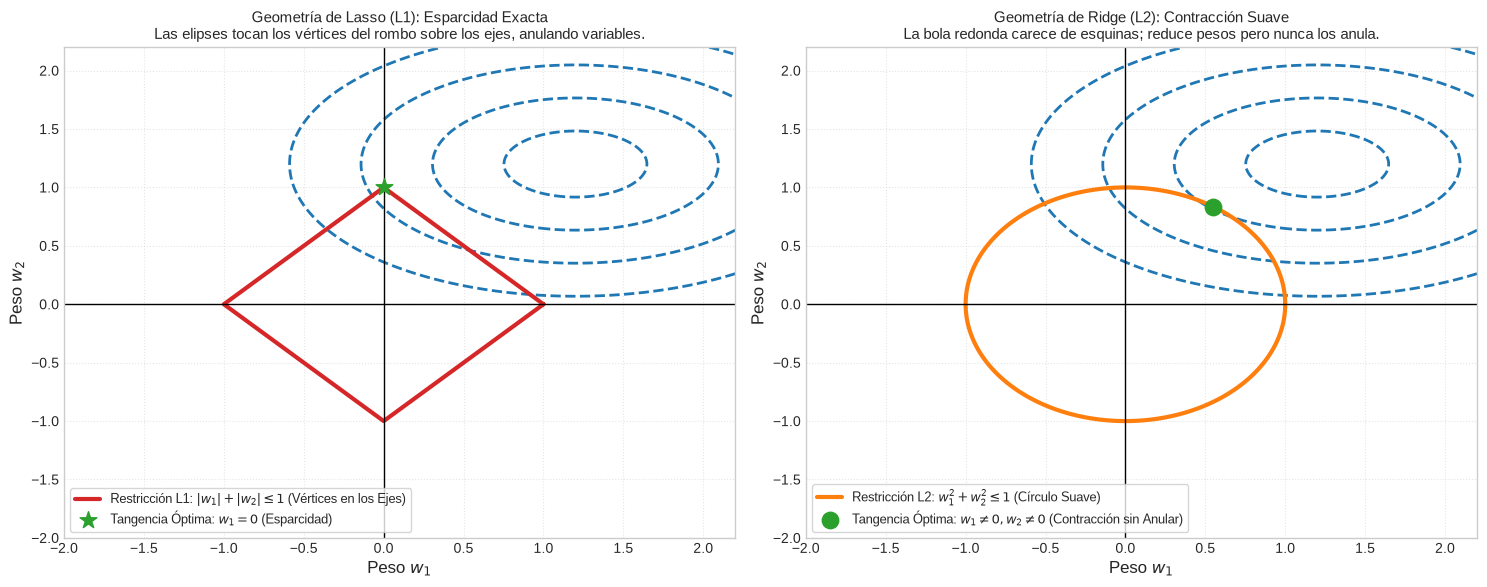

In [23]:
# =============================================================================
# VISUALIZACIÓN: GEOMETRÍA DE ESPARCIDAD (LASSO L1 VS RIDGE L2)
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

w1 = np.linspace(-2.2, 2.2, 400)
w2 = np.linspace(-2.2, 2.2, 400)
W1, W2 = np.meshgrid(w1, w2)

# Función de costo (elipses centradas en (1.2, 1.2))
C = (W1 - 1.2)**2 + 2.5 * (W2 - 1.2)**2

# Panel 1: Lasso (L1)
ax1.contour(W1, W2, C, levels=[0.2, 0.8, 1.8, 3.2], colors='#1f77b4', linestyles='--')
l1_x = [1, 0, -1, 0, 1]
l1_y = [0, 1, 0, -1, 0]
ax1.plot(l1_x, l1_y, color='#d62728', lw=3, label='Restricción L1: $|w_1| + |w_2| \\leq 1$ (Vértices en los Ejes)')
ax1.scatter([0], [1.0], color='#2ca02c', s=160, zorder=5, marker='*', label='Tangencia Óptima: $w_1 = 0$ (Esparcidad)')
ax1.axhline(0, color='k', lw=1)
ax1.axvline(0, color='k', lw=1)
ax1.set_title("Geometría de Lasso (L1): Esparcidad Exacta\nLas elipses tocan los vértices del rombo sobre los ejes, anulando variables.", fontsize=11)
ax1.set_xlabel("Peso $w_1$")
ax1.set_ylabel("Peso $w_2$")
ax1.legend(loc='lower left', frameon=True, fontsize=9)
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.set_xlim(-2.0, 2.2)
ax1.set_ylim(-2.0, 2.2)

# Panel 2: Ridge (L2)
ax2.contour(W1, W2, C, levels=[0.2, 0.8, 1.8, 3.2], colors='#1f77b4', linestyles='--')
theta_circ = np.linspace(0, 2*np.pi, 200)
ax2.plot(np.cos(theta_circ), np.sin(theta_circ), color='#ff7f0e', lw=3, label='Restricción L2: $w_1^2 + w_2^2 \\leq 1$ (Círculo Suave)')
ax2.scatter([0.55], [0.83], color='#2ca02c', s=140, zorder=5, marker='o', label='Tangencia Óptima: $w_1 \\neq 0, w_2 \\neq 0$ (Contracción sin Anular)')
ax2.axhline(0, color='k', lw=1)
ax2.axvline(0, color='k', lw=1)
ax2.set_title("Geometría de Ridge (L2): Contracción Suave\nLa bola redonda carece de esquinas; reduce pesos pero nunca los anula.", fontsize=11)
ax2.set_xlabel("Peso $w_1$")
ax2.set_ylabel("Peso $w_2$")
ax2.legend(loc='lower left', frameon=True, fontsize=9)
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.set_xlim(-2.0, 2.2)
ax2.set_ylim(-2.0, 2.2)

plt.tight_layout()
plt.show()


🔬 Resultados de Selección de Características:
1. Filtro Varianza (>0.2) : 15 variables retenidas -> ['Feature_01', 'Feature_02', 'Feature_03', 'Feature_04', 'Feature_05', 'Feature_06', 'Feature_07', 'Feature_08', 'Feature_09', 'Feature_10', 'Feature_11', 'Feature_12', 'Feature_13', 'Feature_14', 'Feature_15']
2. Filtro ANOVA F-test    : Top-5 variables -> ['Feature_01', 'Feature_02', 'Feature_09', 'Feature_12', 'Feature_14']
3. Wrapper RFE            : Top-5 variables -> ['Feature_01', 'Feature_02', 'Feature_03', 'Feature_12', 'Feature_14']
4. Embebido Lasso (L1)    : 5 variables con coef != 0 -> ['Feature_01', 'Feature_07', 'Feature_09', 'Feature_12', 'Feature_14']


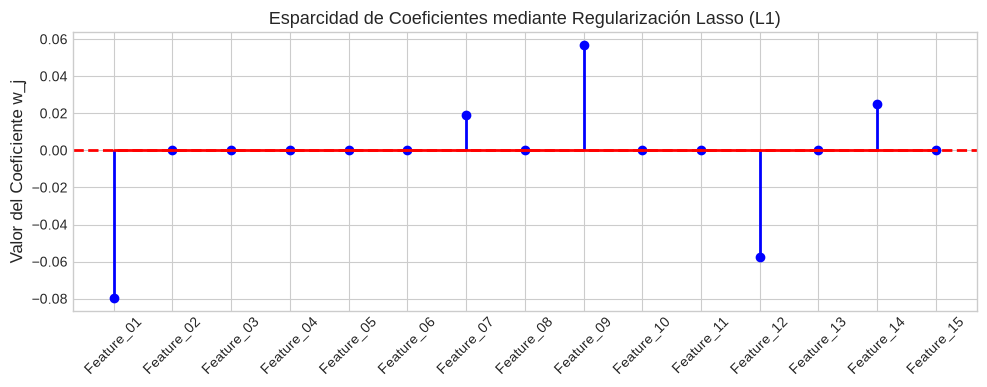

In [24]:
# =============================================================================
# IMPLEMENTACIÓN DE SELECCIÓN DE CARACTERÍSTICAS (FILTRO, WRAPPER Y LASSO)
# =============================================================================
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.linear_model import Lasso

# Generación de dataset con 15 variables: 5 informativas, 2 redundantes, 8 ruido aleatorio
np.random.seed(RANDOM_STATE)
X_fs, y_fs = make_classification(
    n_samples=400,
    n_features=15,
    n_informative=5,
    n_redundant=2,
    n_repeated=0,
    random_state=RANDOM_STATE
)
nombres_vars = [f"Feature_{i+1:02d}" for i in range(15)]

# 1. Filtro: Variance Threshold (eliminación de variables con varianza insignificante)
selector_var = VarianceThreshold(threshold=0.2)
selector_var.fit(X_fs)
vars_retenidas_var = [nombres_vars[i] for i in selector_var.get_support(indices=True)]

# 2. Filtro: SelectKBest con ANOVA F-test (las mejores 5 variables)
selector_kbest = SelectKBest(score_func=f_classif, k=5)
selector_kbest.fit(X_fs, y_fs)
vars_retenidas_kbest = [nombres_vars[i] for i in selector_kbest.get_support(indices=True)]

# 3. Wrapper: Recursive Feature Elimination (RFE) con Regresión Logística
selector_rfe = RFE(estimator=LogisticRegression(random_state=RANDOM_STATE), n_features_to_select=5)
selector_rfe.fit(X_fs, y_fs)
vars_retenidas_rfe = [nombres_vars[i] for i in selector_rfe.get_support(indices=True)]

# 4. Embebido: Regularización Lasso (L1) observando coeficientes anulados
lasso = Lasso(alpha=0.08, random_state=RANDOM_STATE)
lasso.fit(X_fs, y_fs)
vars_retenidas_lasso = [nombres_vars[i] for i, coef in enumerate(lasso.coef_) if abs(coef) > 1e-4]

print("🔬 Resultados de Selección de Características:")
print(f"1. Filtro Varianza (>0.2) : {len(vars_retenidas_var)} variables retenidas -> {vars_retenidas_var}")
print(f"2. Filtro ANOVA F-test    : Top-5 variables -> {vars_retenidas_kbest}")
print(f"3. Wrapper RFE            : Top-5 variables -> {vars_retenidas_rfe}")
print(f"4. Embebido Lasso (L1)    : {len(vars_retenidas_lasso)} variables con coef != 0 -> {vars_retenidas_lasso}")

# Gráfico de coeficientes Lasso que muestra esparcidad
plt.figure(figsize=(10, 4))
plt.stem(range(15), lasso.coef_, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.xticks(range(15), nombres_vars, rotation=45)
plt.title('Esparcidad de Coeficientes mediante Regularización Lasso (L1)')
plt.ylabel('Valor del Coeficiente w_j')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()


<a id="54-sistemas-recomendacion"></a>
## 5.4 Sistemas de Recomendación: Similitud Coseno y Filtrado Colaborativo

Los sistemas de recomendación asisten a usuarios en la toma de decisiones dentro de catálogos masivos. Se dividen en dos paradigmas fundamentales:

### 1. Recomendación Basada en Contenido (Content-Based)
Recomienda ítems similares a los que un usuario consumió y calificó positivamente en el pasado. Se modela cada ítem como un vector de atributos y se evalúa la **Similitud Coseno**:
$$\text{Sim}_{\cos}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|_2 \|\mathbf{v}\|_2}$$

---

### 2. Filtrado Colaborativo Basado en Usuarios (User-Based Collaborative Filtering)
Aprovecha el comportamiento colectivo histórico sin requerir atributos descriptivos de los ítems. Asume que usuarios con preferencias similares en el pasado tenderán a concordar en el futuro.

Para predecir la calificación desconocida del usuario activo $u$ sobre el ítem $i$, se utiliza la **Fórmula con Normalización por la Media (Mean-Centering)**:
$$\hat{r}_{u, i} = \bar{r}_u + \frac{\sum_{v \in U_i} \text{Sim}(u, v) \cdot (r_{v, i} - \bar{r}_v)}{\sum_{v \in U_i} |\text{Sim}(u, v)|}$$

---

### Desglose Minucioso de Cada Término de la Fórmula
* $\hat{r}_{u, i}$: Calificación predicha que el usuario activo $u$ otorgaría al ítem aún no visto $i$.
* $\bar{r}_u = \frac{1}{|I_u|} \sum_{j \in I_u} r_{u, j}$: Calificación promedio histórica otorgada por el usuario $u$ a todos los ítems que ha puntuado. Representa su **sesgo de calificación basal** (un usuario optimista asigna en promedio 4.5; uno crítico asigna 2.5).
* $U_i$: Conjunto de usuarios similares a $u$ que **efectivamente han calificado** el ítem de interés $i$.
* $\text{Sim}(u, v)$: Coeficiente de similitud (Coseno centrado o Correlación de Pearson) entre los usuarios $u$ y $v$, calculado estrictamente sobre los ítems co-calificados por ambos.
* $r_{v, i}$: Calificación real que el vecino similar $v$ otorgó al ítem $i$.
* $\bar{r}_v$: Calificación promedio histórica del vecino $v$.
* $(r_{v, i} - \bar{r}_v)$: **Desviación respecto a la media del vecino**. Indica si al vecino le agradó el ítem por encima o por debajo de su estándar habitual.
* $\sum_{v \in U_i} |\text{Sim}(u, v)|$: Factor de normalización ponderado que garantiza que la predicción combinada permanezca dentro de la escala numérica natural de calificaciones (ej. $[1, 5]$).


<a id="55-recomendador-contenido"></a>
### 5.5 Implementación 1: Recomendador Basado en Contenido
Construimos un catálogo de películas caracterizado por géneros binarios y evaluamos la afinidad de un usuario mediante similitud coseno con su vector de preferencias.


In [25]:
# =============================================================================
# IMPLEMENTACIÓN 1: RECOMENDADOR BASADO EN CONTENIDO
# =============================================================================
from sklearn.metrics.pairwise import cosine_similarity

# Matriz de 7 películas y 6 géneros binarios
peliculas = ['Inception', 'The Dark Knight', 'Interstellar', 'Toy Story', 'Finding Nemo', 'Coco', 'The Notebook']
generos = ['Accion', 'Aventura', 'Sci-Fi', 'Animacion', 'Drama', 'Romance']

matriz_items = np.array([
    [1, 1, 1, 0, 0, 0],  # Inception (Acción, Aventura, Sci-Fi)
    [1, 0, 0, 0, 1, 0],  # The Dark Knight (Acción, Drama)
    [0, 1, 1, 0, 1, 0],  # Interstellar (Aventura, Sci-Fi, Drama)
    [0, 1, 0, 1, 0, 0],  # Toy Story (Aventura, Animación)
    [0, 1, 0, 1, 0, 0],  # Finding Nemo (Aventura, Animación)
    [0, 0, 0, 1, 1, 0],  # Coco (Animación, Drama)
    [0, 0, 0, 0, 1, 1]   # The Notebook (Drama, Romance)
])
df_catalogo = pd.DataFrame(matriz_items, index=peliculas, columns=generos)

# Perfil del usuario activo (preferencia por Sci-Fi y Aventura)
perfil_usuario = np.array([[0.2, 0.8, 1.0, 0.0, 0.4, 0.0]])

# Cómputo de similitud coseno entre el perfil del usuario y el catálogo
similitudes = cosine_similarity(perfil_usuario, df_catalogo.values).flatten()

df_ranking_contenido = pd.DataFrame({
    'Película': peliculas,
    'Afinidad Predicha (Coseno)': similitudes
}).sort_values(by='Afinidad Predicha (Coseno)', ascending=False)

print("🎬 Recomendaciones Basadas en Contenido:")
print(df_ranking_contenido.to_string(index=False))


🎬 Recomendaciones Basadas en Contenido:
       Película  Afinidad Predicha (Coseno)
   Interstellar                    0.936382
      Inception                    0.851257
      Toy Story                    0.417029
   Finding Nemo                    0.417029
The Dark Knight                    0.312772
           Coco                    0.208514
   The Notebook                    0.208514


<a id="56-filtrado-colaborativo-paso-a-paso"></a>
### 5.6 Implementación 2: Filtrado Colaborativo Manual Paso a Paso con Normalización por Media
Modelamos una matriz de interacción Usuario-Ítem con valores faltantes (`NaN`). Calculamos las medias históricas por usuario, las similitudes de Pearson sobre ítems en común y computamos analíticamente cada término de la sumatoria para predecir la calificación de ítems no vistos y ordenar el ranking final de recomendación.


In [26]:
# =============================================================================
# IMPLEMENTACIÓN 2: FILTRADO COLABORATIVO PASO A PASO (USER-BASED CON MEDIA)
# =============================================================================

# Matriz de Calificaciones Usuario - Ítem (con valores NaN en ítems no evaluados)
usuarios = ['Alicia', 'Bernardo', 'Carlos', 'Diana', 'Esteban']
items = ['Inception', 'Interstellar', 'The Dark Knight', 'Toy Story', 'Finding Nemo', 'Coco']

matriz_ratings = np.array([
    [5.0, 5.0, 4.0, np.nan, 1.0, np.nan],  # Alicia (Fan de Nolan/Sci-Fi)
    [4.0, 5.0, np.nan, 2.0, np.nan, 1.0],  # Bernardo (Fan de Nolan/Sci-Fi)
    [np.nan, 2.0, 3.0, 5.0, 4.0, np.nan],  # Carlos (Gusto infantil/animación)
    [1.0, np.nan, 2.0, 5.0, 4.0, 5.0],     # Diana (Fan de animación)
    [2.0, 1.0, 1.0, 4.0, 5.0, 5.0]         # Esteban (Fan de animación)
])

df_ratings = pd.DataFrame(matriz_ratings, index=usuarios, columns=items)
print("📊 Matriz de Interacción Usuario - Ítem Original (Ratings de 1 a 5):")
print(df_ratings)

# Predicción paso a paso para Alicia sobre 'Toy Story'
usuario_activo = 'Alicia'
item_objetivo = 'Toy Story'

# 1. Medias históricas por usuario (r_bar)
medias_usuarios = df_ratings.mean(axis=1)
print(f"\n📈 Calificaciones Promedio Históricas:")
for u, m in medias_usuarios.items():
    print(f"  {u}: {m:.3f}")

# 2. Función para calcular similitud centrada (Pearson Correlation) entre dos usuarios
def calcular_similitud_usuarios(df: pd.DataFrame, u1: str, u2: str) -> float:
    mascara_comun = df.loc[u1].notnull() & df.loc[u2].notnull()
    if np.sum(mascara_comun) < 2:
        return 0.0
    
    r1 = df.loc[u1, mascara_comun].values
    r2 = df.loc[u2, mascara_comun].values
    
    m1 = medias_usuarios[u1]
    m2 = medias_usuarios[u2]
    
    centrado1 = r1 - m1
    centrado2 = r2 - m2
    
    norm1 = np.linalg.norm(centrado1)
    norm2 = np.linalg.norm(centrado2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return float(np.dot(centrado1, centrado2) / (norm1 * norm2))

# 3. Aplicar la fórmula exacta para predecir la calificación de Toy Story para Alicia
media_u = medias_usuarios[usuario_activo]
numerador = 0.0
denominador = 0.0

print(f"\n🧮 Desglose analítico de la sumatoria para '{usuario_activo}' en '{item_objetivo}':")

for vecino in usuarios:
    if vecino == usuario_activo:
        continue
    if pd.notnull(df_ratings.loc[vecino, item_objetivo]):
        sim = calcular_similitud_usuarios(df_ratings, usuario_activo, vecino)
        r_vi = df_ratings.loc[vecino, item_objetivo]
        media_v = medias_usuarios[vecino]
        desviacion = r_vi - media_v
        
        if sim > 0:
            numerador += sim * desviacion
            denominador += abs(sim)
            print(f"  • Vecino {vecino:8s} | Sim={sim:+.4f} | r_vi={r_vi} | Media_v={media_v:.3f} | Desviación={desviacion:+.3f}")
        else:
            print(f"  • Vecino {vecino:8s} | Sim={sim:+.4f} (Descartado por similitud <= 0)")

prediccion_alicia = media_u + (numerador / denominador) if denominador > 0 else media_u
print(f"\n🎯 Resultado Numérico:")
print(f"Predicción r_hat({usuario_activo}, {item_objetivo}) = {media_u:.3f} + ({numerador:.4f} / {denominador:.4f}) = {prediccion_alicia:.2f}")

# 4. Predicción para todos los ítems no calificados de Alicia para generar su Ranking
items_no_vistos = df_ratings.columns[df_ratings.loc[usuario_activo].isnull()]
ranking_alicia = []

for item in items_no_vistos:
    num, den = 0.0, 0.0
    for v in usuarios:
        if v != usuario_activo and pd.notnull(df_ratings.loc[v, item]):
            sim = calcular_similitud_usuarios(df_ratings, usuario_activo, v)
            if sim > 0:
                num += sim * (df_ratings.loc[v, item] - medias_usuarios[v])
                den += abs(sim)
    pred = media_u + (num / den) if den > 0 else media_u
    ranking_alicia.append({'Ítem Recomendable': item, 'Rating Predicho': pred})

df_final_rec = pd.DataFrame(ranking_alicia).sort_values(by='Rating Predicho', ascending=False)
print(f"\n🏆 Ranking Final de Recomendaciones para {usuario_activo}:")
print(df_final_rec.to_string(index=False))


📊 Matriz de Interacción Usuario - Ítem Original (Ratings de 1 a 5):
          Inception  Interstellar  The Dark Knight  Toy Story  Finding Nemo  \
Alicia          5.0           5.0              4.0        NaN           1.0   
Bernardo        4.0           5.0              NaN        2.0           NaN   
Carlos          NaN           2.0              3.0        5.0           4.0   
Diana           1.0           NaN              2.0        5.0           4.0   
Esteban         2.0           1.0              1.0        4.0           5.0   

          Coco  
Alicia     NaN  
Bernardo   1.0  
Carlos     NaN  
Diana      5.0  
Esteban    5.0  

📈 Calificaciones Promedio Históricas:
  Alicia: 3.750
  Bernardo: 3.000
  Carlos: 3.500
  Diana: 3.400
  Esteban: 3.000

🧮 Desglose analítico de la sumatoria para 'Alicia' en 'Toy Story':
  • Vecino Bernardo | Sim=+0.9487 | r_vi=2.0 | Media_v=3.000 | Desviación=-1.000
  • Vecino Carlos   | Sim=-0.6714 (Descartado por similitud <= 0)
  • Vecino Diana   

---

## 🏁 Síntesis Integral y Conclusiones Generales (Clases 1 a 5)

A lo largo de este Cuaderno Maestro hemos recorrido el núcleo matemático y algorítmico del aprendizaje automático supervisado y la preparación de datos:

1. **Clase 1 (Métricas de Distancia)**: Comprendimos que toda noción de proximidad geométrica en Machine Learning ($L_1$, $L_2$, $L_p$, Coseno) induce sesgos inductivos específicos sobre el espacio de estados. La distancia Coseno es fundamental para datos no acotados e invariantes a magnitud, mientras que Manhattan ofrece robustez ante outliers.
2. **Clase 2 (EDA y Preprocesamiento)**: La rigurosidad metodológica exige blindar el conjunto de prueba para evitar **Data Leakage**. La estandarización Z-score y la normalización Min-Max preparan a los datos para que algoritmos sensibles a distancias como KNN operen de manera equilibrada.
3. **Clase 3 (Árboles de Decisión)**: Las métricas de impureza (Entropía y Gini) guían la partición óptima del espacio. Gini provee eficiencia computacional equivalente a Entropía sin evaluar funciones trascendentales, siendo el estándar de CART.
4. **Clase 4 (Métricas y Ensambles)**: Diagnosticar modelos requiere trascender el Accuracy mediante matrices de confusión, curvas ROC y AUC. Los ensambles explotan el principio de complementariedad: **Bagging** mitiga la varianza promediando modelos independientes; **Boosting** reduce el sesgo iterando sobre los errores residuales; **Stacking** optimiza la combinación de predictores heterogéneos.
5. **Clase 5 (Desbalance, Selección y Recomendación)**: SMOTE sintetiza muestras interpolando sobre vectores directores en la minoría y la ponderación de costos compensa la disparidad en la función de pérdida. La regularización Lasso ($L_1$) elimina coeficientes espurios por esparcidad geométrica. Finalmente, el filtrado colaborativo con normalización por la media desacopla los sesgos intrínsecos de los usuarios para estimar valoraciones con alta fidelidad.

---
**Cátedra de Minería de Datos y Aprendizaje Automático — Facultad de Informática, UNLP (2026)**
